<a href="https://colab.research.google.com/github/walterCNeto/Modelagem/blob/main/PortOpt_ClassNotes_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mean-Variance and Utility Optimization

Case 1 - Portfolio comprising two risky instruments and no short-selling

In [1]:
import pandas as pd
import numpy as np
import scipy as sc
import random as rd
import seaborn as sns
import yfinance as yf  # noqa
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import norm
from IPython.display import display, Latex

R1 = 0.10; S1 = 0.15
R2 = 0.30; S2 = 0.40
Rp = lambda w1: w1*R1 + (1-w1)*R2
Sp = lambda w1, p: np.sqrt(w1**2 * S1**2 + 2*w1*(1-w1)*S1*S2*p + (1-w1)**2*S2**2)

Let's set $\omega$ = 0.0, 0.01, ..., 1.0

Then, for $\rho$ = +0.1, +0.5, 0.0, -0.5, -1.0:

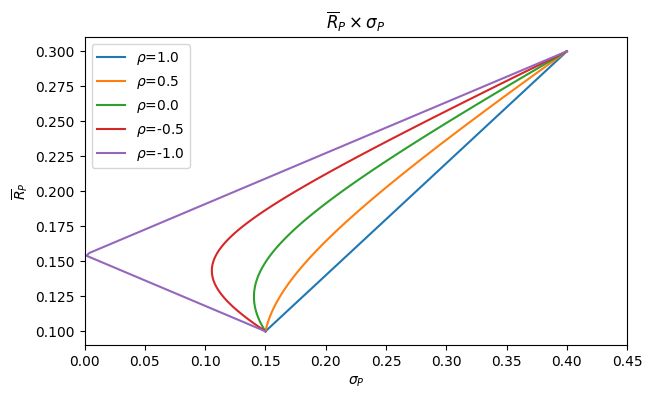

In [2]:
# @title
w1 = np.arange(0.0, 1.01, 0.01)
rhos = [1.0, 0.5, 0.0, -0.5, -1.0]

plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.45])
plt.ylabel("$\overline{R}_P$")

for p in rhos:

  y = [Rp(w) for w in w1]
  x = [Sp(w, p) for w in w1]

  plt.plot(x, y, label=r"$\rho$=%0.1f" % p)

plt.legend()

Notice that not all possible values for $\omega_1$ lead to efficient portfolios, in the sense that they achieve the maximum expected return for a given level of volatility. Only points *above* the Minimum Variance Portfolios (MVPs) should be considered *efficient*.

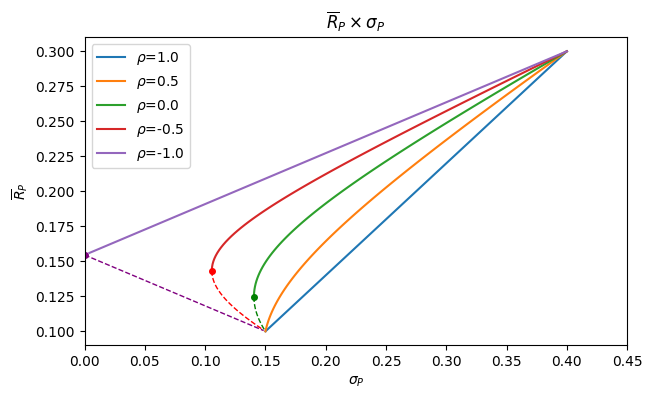

In [3]:
w_mvps = [(S2**2 - S1*S2*p)/(S1**2 + S2**2 - 2*S1*S2*p) for p in rhos]
w_mvps

plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.45])
plt.ylabel("$\overline{R}_P$")

for i, p in enumerate(rhos):

  # Efficient region (*i.e., with expected returns below the MVP)
  w1 = np.arange(0.0, np.minimum(w_mvps[i], 1.01), 0.01)

  y = [Rp(w) for w in w1]
  x = [Sp(w, p) for w in w1]

  plt.plot(x, y, label=r"$\rho$=%0.1f" % p)

colors = ["blue", "orange", "green", "red", "purple"]
for i, p in enumerate(rhos):

  # Inefficient region (*i.e., with expected returns above or equal the MVP)
  w1 = np.arange(np.maximum(w_mvps[i], 0.0), 1.0, 0.01)

  y = [Rp(w) for w in w1]
  x = [Sp(w, p) for w in w1]

  # plt.title(r"$\overline{R}_P \times \sigma_P$ for $\rho$ = %0.1f" % p)
  plt.plot(x, y, color=colors[i], linestyle='dashed', linewidth=1)
  if w_mvps[i] <= 1.0:
    plt.plot(Sp(w_mvps[i], p), Rp(w_mvps[i]), color=colors[i], marker='o', markersize=4)

plt.legend()


Recall that:
$$
w_1 = \frac{\sigma^2_2 - \sigma_1\sigma_2\rho_{1,2}}{\sigma^1_2 + \sigma^2_2 - 2\times\sigma_1\sigma_2\rho_{1,2}}
$$
Then, for $\rho_{1,2} = -0.5$ we have:

In [4]:
p = -0.5
w1 = (S2**2 - S1*S2*p)/(S1**2 + S2**2 - 2*S1*S2*p)
display(Latex(r"$\omega_1 = %.4f$" % w1))

<IPython.core.display.Latex object>

In [5]:
display(Latex(r"$\sigma_P = %.4f$" % Sp(w1, p)))

<IPython.core.display.Latex object>

In [6]:
w1 = sc.optimize.fminbound(func=Sp, x1=0.0, x2=1.0, args=[-0.5], xtol=1e-05, disp=3)
display(Latex(r"$\omega_1 = %.4f$" % w1))

 
 Func-count     x          f(x)          Procedure
    1       0.381966     0.224128        initial
    2       0.618034     0.133319        golden
    3       0.763932     0.105957        golden
    4       0.872668     0.114289        parabolic
    5       0.781371     0.105523        parabolic
    6       0.783845     0.105518        parabolic
    7       0.783507     0.105518        parabolic
    8       0.783504     0.105518        parabolic
    9       0.783501     0.105518        parabolic

Optimization terminated successfully;
The returned value satisfies the termination criteria
(using xtol =  1e-05 )


<IPython.core.display.Latex object>

In [7]:
display(Latex(r"$\sigma_P = %.4f$" % Sp(w1, p)))

<IPython.core.display.Latex object>

In [8]:
w1 = sc.optimize.fminbound(Rp, 0.0, 1.0, args=[], xtol=1e-05, disp=3)
display(Latex(r"$\omega_1 = %.4f$" % w1))

 
 Func-count     x          f(x)          Procedure
    1       0.381966     0.223607        initial
    2       0.618034     0.176393        golden
    3       0.763932     0.147214        golden
    4       0.854102      0.12918        golden
    5        0.90983     0.118034        golden
    6       0.944272     0.111146        golden
    7       0.965558     0.106888        golden
    8       0.978714     0.104257        golden
    9       0.986844     0.102631        golden
   10       0.991869     0.101626        golden
   11       0.994975     0.101005        golden
   12       0.996894     0.100621        golden
   13       0.998081     0.100384        golden
   14       0.998814     0.100237        golden
   15       0.999267     0.100147        golden
   16       0.999547     0.100091        golden
   17        0.99972     0.100056        golden
   18       0.999827     0.100035        golden
   19       0.999893     0.100021        golden
   20       0.999934     0.100013 

<IPython.core.display.Latex object>

In [9]:
w1 = sc.optimize.fminbound(lambda w: -Rp(w), 0.0, 1.0, args=[], xtol=1e-05, disp=3)
display(Latex(r"$\omega_1 = %.4f$" % w1))

 
 Func-count     x          f(x)          Procedure
    1       0.381966    -0.223607        initial
    2       0.618034    -0.176393        golden
    3       0.236068    -0.252786        golden
    4       0.145898     -0.27082        golden
    5      0.0901699    -0.281966        golden
    6      0.0557281    -0.288854        golden
    7      0.0344419    -0.293112        golden
    8      0.0212862    -0.295743        golden
    9      0.0131556    -0.297369        golden
   10     0.00813062    -0.298374        golden
   11       0.005025    -0.298995        golden
   12     0.00310562    -0.299379        golden
   13     0.00191938    -0.299616        golden
   14     0.00118624    -0.299763        golden
   15    0.000733137    -0.299853        golden
   16    0.000453104    -0.299909        golden
   17    0.000280034    -0.299944        golden
   18     0.00017307    -0.299965        golden
   19    0.000106963    -0.299979        golden
   20     6.6107e-05    -0.299987 

<IPython.core.display.Latex object>

The definition of the linear constraint depends on choosen the optimization method.

For instance, let's use the SLSQP method to handle the constraint:
$\overline{R}_P = \omega_1\overline{R}_1 + (1 - \omega_1)\overline{R}_2 = \omega_1 \begin{pmatrix} \overline{R}_1 - \overline{R}_2 \end{pmatrix} + \overline{R}_2 \geqslant \mu_{min} = 0.20$

Reordering the terms, the inequality constraint becomes:
$\omega_1 \begin{pmatrix} \overline{R}_1 - \overline{R}_2 \end{pmatrix} + \overline{R}_2 - \mu_{min} \geqslant 0$


In [10]:
p = -0.5
mu_min = 0.20
cons = {"type": "ineq", "fun": lambda w: w*(R1 - R2) + R2 - mu_min}
w1 = sc.optimize.minimize(fun=Sp, x0=0.0, args=[p], method="SLSQP", jac=None, hess=None, hessp=None, bounds=[(0.0, 1.0)], constraints=cons, tol=1e-05)
print(w1)
display(Latex(r"$\rho_{1,2} = %.2f$" % p))
display(Latex(r"$\omega_1 = %.4f$" % w1.x[0]))
display(Latex(r"$\overline{R}_P = %.4f$" % Rp(w1.x[0])))
display(Latex(r"$\sigma_P = %.4f$" % Sp(w1.x[0], p)))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.17499999996341167
       x: [ 5.000e-01]
     nit: 3
     jac: [-3.929e-01]
    nfev: 6
    njev: 3


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

For the maximum volatility constraint, we have:
$\Sigma_P = \omega_1^1\sigma_1^2 + 2\omega_1(1 - \omega_1)\sigma_1\sigma_2\rho_{1,2} + (1 - \omega_1)^2\sigma_2^2 \leqslant \sigma_{max}^2 = 0.20^2$

Reordering the terms, the inequality constraint becomes:
$-\begin{pmatrix}\omega_1^1\sigma_1^2 + 2\omega_1(1 - \omega_1)\sigma_1\sigma_2\rho_{1,2} + (1 - \omega_1)^2\sigma_2^2 \end{pmatrix} + \sigma_{max}^2\geqslant 0$


In [11]:
p = -0.5
sig_max = 0.20
cons = {"type": "ineq", "fun": lambda w: -(w**2*S1**2 + 2*w*(1-w)*S1*S2*p + (1-w)**2*S2**2) + sig_max**2}
w1 = sc.optimize.minimize(fun=lambda w: -Rp(w), x0=0.0, method="SLSQP", jac=None, hess=None, hessp=None, bounds=[(0.0, 1.0)], constraints=cons, tol=1e-05)
print(w1)
display(Latex(r"$\rho_{1,2} = %.2f$" % p))
display(Latex(r"$\omega_1 = %.4f$" % w1.x[0]))
display(Latex(r"$\overline{R}_P = %.4f$" % Rp(w1.x[0])))
display(Latex(r"$\sigma_P = %.4f$" % Sp(w1.x[0], p)))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.21230189510624373
       x: [ 4.385e-01]
     nit: 5
     jac: [ 2.000e-01]
    nfev: 10
    njev: 5


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Case 2 - Portfolio comprising multiple risky instruments and no short-selling

In [12]:
mu = np.array([[0.10, 0.15, 0.20, 0.25, 0.30]]).reshape(-1, 1)  # Expected Returns array 1 x N
sig = np.array([[0.10, 0.20, 0.30, 0.40, 0.50]]).reshape(-1, 1)  # Volatilities array 1 x N
rho = np.array(
    [[+1.00, -0.25, -0.10,  0.00, +0.10],
     [-0.25, +1.00, +0.30, +0.60, +0.00],
     [-0.10, +0.30, +1.00, +0.50, +0.10],
     [ 0.00, +0.60, +0.50, +1.00, -0.25],
     [+0.10, +0.00, +0.10, -0.25, +1.00]]
)  # Correlation matrix N x N
covs = np.diag(sig.flatten()) @ rho @ np.diag(sig.flatten())  # Covariance matrix N x N

# Check if eigenvalues are positive
if np.linalg.det(covs) < 0:
  print("Not all eigenvalues of the covariance matrix are non-zero")

# Check if matrix is symmetric (accounting for possible rounding errors)
covs_rounded = np.round(covs, decimals=8)
if not np.array_equal(covs_rounded, np.transpose(covs_rounded)):
  print("Covariance matrix is not symmetric")
else:
  covs = (covs + np.transpose(covs)) / 2  # Mitigate possible rounding errors

N = mu.shape[0]

In [13]:
Rp = lambda ws: (ws.T @ mu)[0]  # Portfolio's Expected Return
Sp = lambda ws, covs: ws.T @ covs @ ws  # Portfolio's Variance (= Volatility^2)

Let's generate 100.000 random portfolio allocations:

In [14]:
M = 100000  # 100k different portfolios
ws = np.random.random([M, N])  # Generate random weights between 0 and 1
ws = ws / np.sum(ws, axis=1).reshape(-1, 1)  # Normalize weights such that they sum up to 1

In [15]:
np.round(ws[0:10, :], decimals=2)

array([[0.29, 0.3 , 0.12, 0.19, 0.1 ],
       [0.27, 0.18, 0.28, 0.  , 0.26],
       [0.23, 0.37, 0.12, 0.22, 0.05],
       [0.26, 0.15, 0.16, 0.4 , 0.03],
       [0.42, 0.09, 0.01, 0.35, 0.13],
       [0.22, 0.28, 0.13, 0.35, 0.01],
       [0.33, 0.35, 0.2 , 0.05, 0.07],
       [0.08, 0.22, 0.03, 0.5 , 0.17],
       [0.15, 0.16, 0.35, 0.31, 0.03],
       [0.  , 0.05, 0.1 , 0.48, 0.37]])

In [16]:
# Check the expected return and volatility of one of the randomly generated allocations
print("Portfolio[0]'s expected return: %.4f" % Rp(ws[0, :]))
print("portfolio[0]'s volatility: %.4f" % np.sqrt(Sp(ws[0, :], covs)))

Portfolio[0]'s expected return: 0.1753
portfolio[0]'s volatility: 0.1457


Now, let's plot the expected returns and volatilities of these random portfolios:

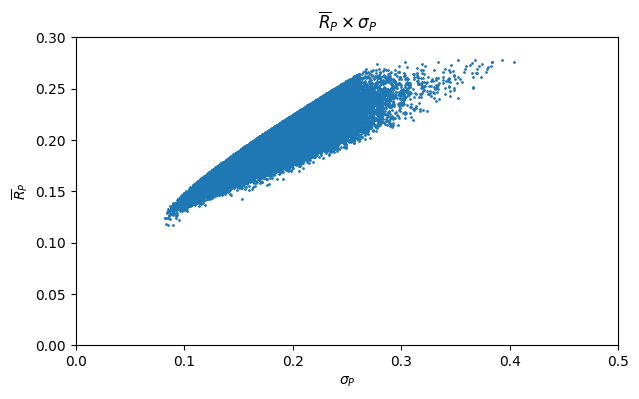

In [17]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.50])
plt.ylim([0.00, 0.30])
plt.ylabel("$\overline{R}_P$")

y = [Rp(w) for w in ws]
x = [np.sqrt(Sp(w, covs)) for w in ws]

plt.scatter(x, y, s=1)

Let's identify the MVP:

In [18]:
w0 = [0.0 for _ in range(N)]  # Initial weights set to zero
bounds = [(0.0, 1.0) for _ in range(N)]  # Weights must be between 0 and 1
cons = {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
res_mvp = sc.optimize.minimize(fun=Sp, x0=w0, args=[covs], method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)
print(res_mvp)
ws_mvp = res_mvp.x
Rp_mvp = Rp(ws_mvp)
Volp_mvp = np.sqrt(Sp(ws_mvp, covs))
display(Latex(r"$\omega = [%s]]" % ",".join("%.2f" % res_mvp.x[i] for i in range(N))))  # MVP allocation weights
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_mvp))  # MVP expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_mvp))  # MVP volatility (same as np.sqrt(res_mvp.fun))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.00605440511020637
       x: [ 7.229e-01  2.214e-01  4.391e-02  9.324e-18  1.170e-02]
     nit: 12
     jac: [ 1.210e-02  1.207e-02  1.189e-02  2.536e-02  1.439e-02]
    nfev: 72
    njev: 12


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

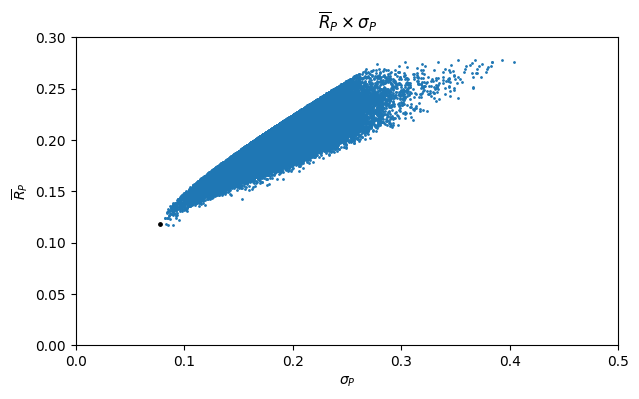

In [19]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.50])
plt.ylim([0.00, 0.30])
plt.ylabel("$\overline{R}_P$")

plt.scatter(x, y, s=1)
plt.scatter(Volp_mvp, Rp_mvp, s=6, c="black")

In [20]:
w0 = [0.0 for _ in range(N)]  # Initial weights set to zero
bounds = [(0.0, 1.0) for _ in range(N)]  # Weights must be between 0 and 1
tgt_vol = 0.08
cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: -Sp(ws, covs) + tgt_vol**2}  # Sp(ws, covs) <= 0.08**2 => -Sp(ws, covs) + 0.08**2 >= 0.0
]
res = sc.optimize.minimize(fun=lambda w: -Rp(w), x0=w0, method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)
print(res)
ws_0 = res.x
Rp_0 = Rp(ws_0)
Volp_0 = np.sqrt(Sp(ws_0, covs))
display(Latex(r"$\omega = [%s]]" % ",".join("%.2f" % res.x[i] for i in range(N))))  # MVP allocation weights
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_0))  # Optimal expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_0))  # Targeted volatility (same as np.sqrt(res_mvp.fun))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.12600741877164018
       x: [ 6.587e-01  2.332e-01  7.267e-02  0.000e+00  3.541e-02]
     nit: 9
     jac: [-1.000e-01 -1.500e-01 -2.000e-01 -2.500e-01 -3.000e-01]
    nfev: 54
    njev: 9


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

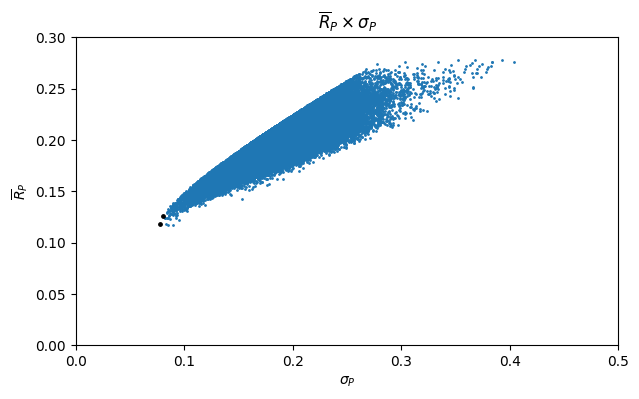

In [21]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.50])
plt.ylim([0.00, 0.30])
plt.ylabel("$\overline{R}_P$")

plt.scatter(x, y, s=1)
plt.scatter([Volp_mvp, Volp_0], [Rp_mvp, Rp_0], s=6, c="black")

In [22]:
ws_EF = [ws_mvp]
x_EF =[Volp_mvp]
y_EF =[Rp_mvp]

ws_EF.append(ws_0)
x_EF.append(Volp_0)
y_EF.append(Rp_0)

w0 = np.array([0.0 for _ in range(N)])  # Initial weights set to zero
bounds = [(0.0, 1.0) for _ in range(N)]  # Weights must be between 0 and 1
tgt_vols = np.arange(0.085, 0.41, 0.005)  # Targeted volatilities between 0.085 and 0.400
for i, tgt_vol in enumerate(tgt_vols):

  cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: -Sp(ws, covs) + tgt_vol**2}  # Sp(ws, covs) <= tgt_vol**2 => -Sp(ws, covs) + tgt_vol**2 >= 0.0
  ]
  res = sc.optimize.minimize(fun=lambda w: -Rp(w), x0=w0, method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)

  ws_i = res.x
  Rp_i = Rp(ws_i)
  Volp_i = np.sqrt(Sp(ws_i, covs))

  # print("Optimization %i/%i: %s (Rp=%.4f, Volp=%.4f)" % (i + 1, len(tgt_vols), res.message, Rp_i, Volp_i))

  ws_EF.append(ws_i)
  x_EF.append(Volp_i)
  y_EF.append(Rp_i)

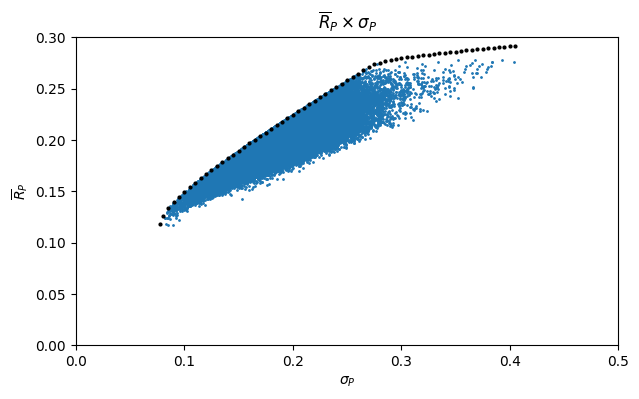

In [23]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.50])
plt.ylim([0.00, 0.30])
plt.ylabel("$\overline{R}_P$")

plt.scatter(x, y, s=1)
plt.scatter(x_EF, y_EF, s=4, c="black")

Text(0.25, 0.13, 'Sub-Optimal\nPortfolio')

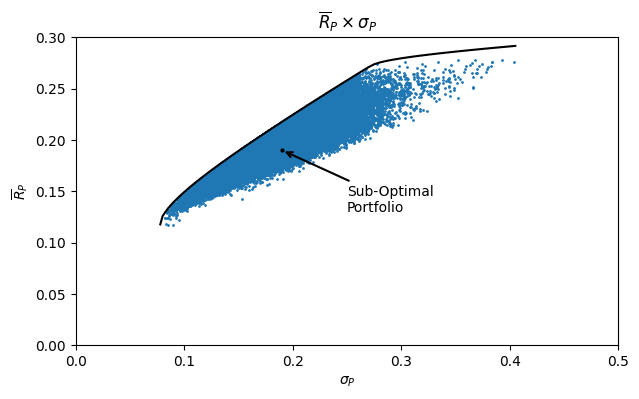

In [24]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.50])
plt.ylim([0.00, 0.30])
plt.ylabel("$\overline{R}_P$")

plt.scatter(x, y, s=1)
plt.plot(x_EF, y_EF, color="black")

# Show an example of a sub-optimal portfolio
subopt_port = (0.190, 0.190)
subopt_port_txt = (0.250, 0.130)
plt.plot(subopt_port[0], subopt_port[1], marker="o", color="black", markersize=2)
plt.annotate('Sub-Optimal\nPortfolio', xy=subopt_port, xytext=subopt_port_txt, arrowprops=dict(arrowstyle='->',lw=1.5))

In [25]:
np.round(ws_EF, decimals=2)[:20, :]

array([[0.72, 0.22, 0.04, 0.  , 0.01],
       [0.66, 0.23, 0.07, 0.  , 0.04],
       [0.61, 0.24, 0.09, 0.01, 0.06],
       [0.59, 0.22, 0.09, 0.03, 0.07],
       [0.56, 0.21, 0.09, 0.05, 0.09],
       [0.54, 0.2 , 0.09, 0.07, 0.1 ],
       [0.53, 0.19, 0.09, 0.09, 0.11],
       [0.51, 0.18, 0.09, 0.1 , 0.13],
       [0.49, 0.17, 0.08, 0.12, 0.14],
       [0.47, 0.16, 0.08, 0.14, 0.15],
       [0.46, 0.15, 0.08, 0.15, 0.16],
       [0.44, 0.14, 0.08, 0.17, 0.17],
       [0.43, 0.13, 0.08, 0.18, 0.18],
       [0.41, 0.12, 0.08, 0.2 , 0.19],
       [0.39, 0.11, 0.08, 0.21, 0.2 ],
       [0.38, 0.11, 0.08, 0.23, 0.21],
       [0.36, 0.1 , 0.08, 0.24, 0.22],
       [0.35, 0.09, 0.08, 0.25, 0.23],
       [0.33, 0.08, 0.08, 0.27, 0.24],
       [0.31, 0.08, 0.07, 0.28, 0.25]])

In [26]:
ws_EF2 = [ws_mvp]
x_EF2 =[Volp_mvp]
y_EF2 =[Rp_mvp]

w0 = np.array([0.0 for _ in range(N)])  # Initial weights set to zero
bounds = [(0.0, 1.0) for _ in range(N)]  # Weights must be between 0 and 1
tgt_mus = np.arange(0.120, 0.295, 0.005)  # Targeted expected returns between 0.120 and 0.295
for i, tgt_mu in enumerate(tgt_mus):

  cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: Rp(ws) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
  ]
  res = sc.optimize.minimize(fun=Sp, x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)

  ws_i2 = res.x
  Rp_i2 = Rp(ws_i2)
  Volp_i2 = np.sqrt(Sp(ws_i2, covs))

  # print("Optimization %i/%i: %s (Rp=%.4f, Volp=%.4f)" % (i + 1, len(tgt_vols), res.message, Rp_i, Volp_i))

  ws_EF2.append(ws_i2)
  x_EF2.append(Volp_i2)
  y_EF2.append(Rp_i2)

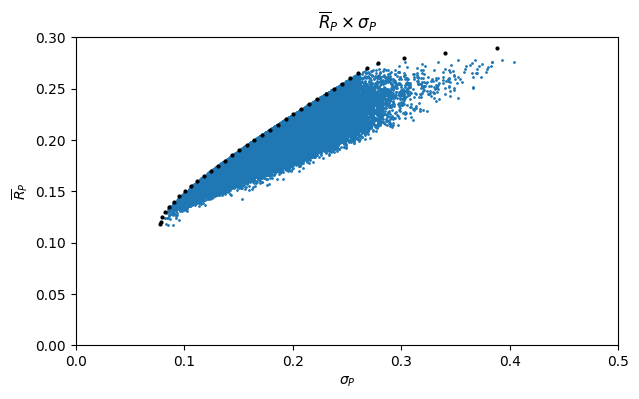

In [27]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.50])
plt.ylim([0.00, 0.30])
plt.ylabel("$\overline{R}_P$")

plt.scatter(x, y, s=1)
plt.scatter(x_EF2, y_EF2, s=4, c="black")

Let's see what happens when we limit the instruments' allocation weights between 0.10 and 0.50:

In [28]:
w0 = [0.0 for _ in range(N)]  # Initial weights set to zero
bounds = [(0.1, 0.5) for _ in range(N)]  # Weights must be between 0.10 and 0.50
cons = {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
res_mvp3 = sc.optimize.minimize(fun=Sp, x0=w0, args=[covs], method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)
print(res_mvp3)
ws_mvp3 = res_mvp3.x
Rp_mvp3 = Rp(ws_mvp3)
Volp_mvp3 = np.sqrt(Sp(ws_mvp3, covs))
display(Latex(r"$\omega = [%s]]" % ",".join("%.2f" % res_mvp3.x[i] for i in range(N))))  # MVP allocation weights
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_mvp3))  # MVP expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_mvp3))  # MVP volatility (same as np.sqrt(res_mvp.fun))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.011440000000000006
       x: [ 5.000e-01  2.000e-01  1.000e-01  1.000e-01  1.000e-01]
     nit: 7
     jac: [ 8.400e-03  2.420e-02  3.720e-02  5.320e-02  4.800e-02]
    nfev: 42
    njev: 7


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [29]:
ws_EF3 = [ws_mvp3]
x_EF3 =[Volp_mvp3]
y_EF3 =[Rp_mvp3]

w0 = np.array([0.0 for _ in range(N)])  # Initial weights set to zero
bounds = [(0.1, 0.5) for _ in range(N)]  # Weights must be between 0.10 and 0.50
tgt_mus = np.arange(0.155, 0.245, 0.0025)  # Targeted expected returns between 0.1550 and 0.300
for i, tgt_mu in enumerate(tgt_mus):

  cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: Rp(ws) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
  ]
  res = sc.optimize.minimize(fun=Sp, x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)

  ws_i3 = res.x
  Rp_i3 = Rp(ws_i3)
  Volp_i3 = np.sqrt(Sp(ws_i3, covs))

  # print("Optimization %i/%i (success: %s): %s (Rp=%.4f, Volp=%.4f)" % (i + 1, len(tgt_mus), res.success, res.message, Rp_i3, Volp_i3))

  if res.success:
    ws_EF3.append(ws_i3)
    x_EF3.append(Volp_i3)
    y_EF3.append(Rp_i3)

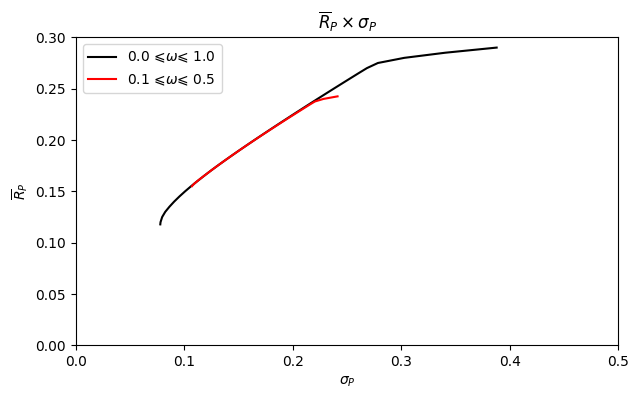

In [30]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.50])
plt.ylim([0.00, 0.30])
plt.ylabel("$\overline{R}_P$")

plt.plot(x_EF2, y_EF2, color="black", label=r"0.0 $\leqslant \omega \leqslant$ 1.0")
plt.plot(x_EF3, y_EF3, color="red", label=r"0.1 $\leqslant \omega \leqslant$ 0.5")
plt.legend()

In [31]:
ws_EF3[-10:]

[array([0.19731086, 0.1       , 0.1       , 0.31075655, 0.29193259]),
 array([0.18272445, 0.1       , 0.1       , 0.3191022 , 0.29817335]),
 array([0.16824205, 0.1       , 0.1       , 0.32703182, 0.30472614]),
 array([0.1540624 , 0.1       , 0.1       , 0.33375041, 0.31218719]),
 array([0.13933189, 0.1       , 0.1       , 0.34267245, 0.31799567]),
 array([0.12493594, 0.1       , 0.1       , 0.35025625, 0.32480781]),
 array([0.11071859, 0.1       , 0.1       , 0.35712563, 0.33215578]),
 array([0.1 , 0.1 , 0.1 , 0.35, 0.35]),
 array([0.1, 0.1, 0.1, 0.3, 0.4]),
 array([0.1       , 0.1       , 0.1       , 0.25000001, 0.44999999])]

Let's see what happens when we allow the instruments' allocation weights to vary between -0.25 and 1.25:

In [32]:
w0 = [0.0 for _ in range(N)]  # Initial weights set to zero
bounds = [(-0.25, 1.25) for _ in range(N)]  # Weights must be between -0.50 and 1.50
cons = {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
res_mvp4 = sc.optimize.minimize(fun=Sp, x0=w0, args=[covs], method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)
print(res_mvp4)
ws_mvp4 = res_mvp4.x
Rp_mvp4 = Rp(ws_mvp4)
Volp_mvp4 = np.sqrt(Sp(ws_mvp4, covs))
display(Latex(r"$\omega = [%s]]" % ",".join("%.2f" % res_mvp4.x[i] for i in range(N))))  # MVP allocation weights
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_mvp4))  # MVP expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_mvp4))  # MVP volatility (same as np.sqrt(res_mvp.fun))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.005390474129095954
       x: [ 7.161e-01  3.094e-01  9.692e-02 -1.045e-01 -1.800e-02]
     nit: 9
     jac: [ 1.040e-02  1.130e-02  1.057e-02  9.130e-03  1.268e-02]
    nfev: 55
    njev: 9


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [33]:
ws_EF4 = [ws_mvp4]
x_EF4 =[Volp_mvp4]
y_EF4 =[Rp_mvp4]

w0 = np.array([0.0 for _ in range(N)])  # Initial weights set to zero
bounds = [(-0.25, 1.25) for _ in range(N)]  # Weights must be between -0.25 and 1.25
tgt_mus = np.arange(0.110, 0.400, 0.0025)  # Targeted expected returns between 0.110 and 0.400
for i, tgt_mu in enumerate(tgt_mus):

  cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: Rp(ws) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
  ]
  res = sc.optimize.minimize(fun=Sp, x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-05)

  ws_i4 = res.x
  Rp_i4 = Rp(ws_i4)
  Volp_i4 = np.sqrt(Sp(ws_i4, covs))

  # print("Optimization %i/%i: %s (Rp=%.4f, Volp=%.4f)" % (i + 1, len(tgt_vols), res.message, Rp_i4, Volp_i4))

  if res.success:
    ws_EF4.append(ws_i4)
    x_EF4.append(Volp_i4)
    y_EF4.append(Rp_i4)

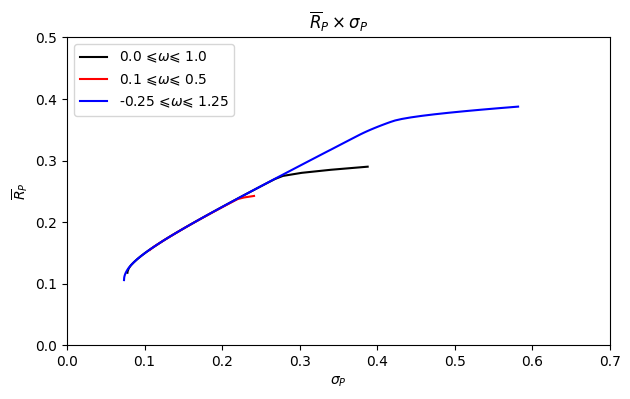

In [34]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.00, 0.70])
plt.ylim([0.00, 0.50])
plt.ylabel("$\overline{R}_P$")

plt.plot(x_EF2, y_EF2, color="black", label=r"0.0 $\leqslant \omega \leqslant$ 1.0")
plt.plot(x_EF3, y_EF3, color="red", label=r"0.1 $\leqslant \omega \leqslant$ 0.5")
plt.plot(x_EF4, y_EF4, color="blue", label=r"-0.25 $\leqslant \omega \leqslant$ 1.25")
plt.legend()

Minimum Variance Portfolios for each case:

In [35]:
display(Latex(r"$ 0.10 \leqslant \omega \leqslant 0.50: \omega = [%s], \sigma_P = %.4f$" % (",".join("%.2f" % ws_EF3[0][i] for i in range(N)), x_EF3[0])))
display(Latex(r"$ 0.00 \leqslant \omega \leqslant 1.00: \omega = [%s], \sigma_P = %.4f$" % (",".join("%.2f" % ws_EF2[0][i] for i in range(N)), x_EF2[0])))
display(Latex(r"$ -0.25 \leqslant \omega \leqslant 1.25: \omega = [%s], \sigma_P = %.4f$" % (",".join("%.2f" % ws_EF4[0][i] for i in range(N)), x_EF4[0])))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [36]:
display(Latex(r"$ 0.10 \leqslant \omega \leqslant 0.50: \omega = [%s], \overline{R}_P = %.4f$" % (",".join("%.2f" % ws_EF3[-1][i] for i in range(N)), y_EF3[-1])))
display(Latex(r"$ 0.00 \leqslant \omega \leqslant 1.00: \omega = [%s], \overline{R}_P = %.4f$" % (",".join("%.2f" % ws_EF2[-1][i] for i in range(N)), y_EF2[-1])))
display(Latex(r"$ -0.25 \leqslant \omega \leqslant 1.25: \omega = [%s], \overline{R}_P = %.4f$" % (",".join("%.2f" % ws_EF4[-1][i] for i in range(N)), y_EF4[-1])))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Now let's see an example with real instruments.

We'll start by getting their monthly log-returns

In [37]:
# Get stock index prices
start_date = "2008-12-31"
end_date = "2023-12-31"
names = ["Ibovespa", "S&P 500", "US10y Tsy", "Brent Oil", "Corn"]
tickers = ["^BVSP", "^GSPC", "ZN=F", "BZ=F", "ZC=F"]
prices = pd.DataFrame(columns=names, dtype=float)
for i, ticker in enumerate(tickers):
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
  prices[names[i]] = data["Close"].rename(names[i])

prices.dropna(inplace=True)  # Drop nans (not the best approach to deal with missing values)
k = 21  # Non-overlapping log-returns for every 21-days
logrets = np.log1p(prices.iloc[::k, :].pct_change())
logrets.dropna(inplace=True)

In [38]:
print("Sample size: %i 21-d log-returns between %s and %s" % (len(logrets), logrets.index[0].strftime("%d/%m/%Y"), logrets.index[-1].strftime("%d/%m/%Y")))

Sample size: 169 21-d log-returns between 04/02/2009 and 14/12/2023


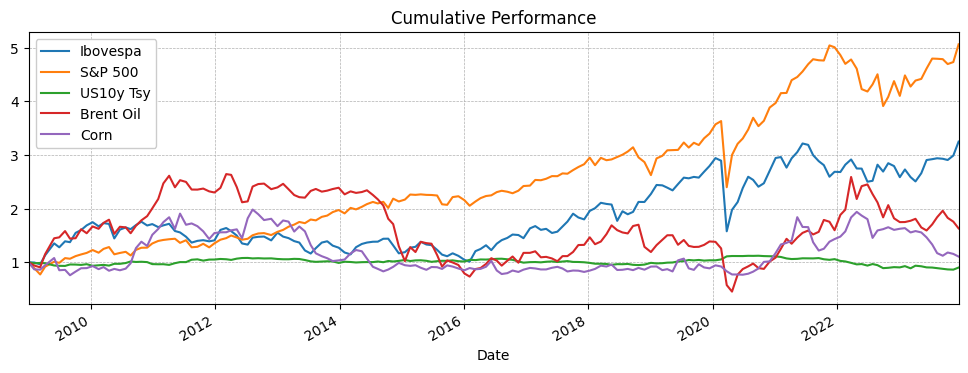

In [39]:
cum_perf = np.exp(logrets.cumsum())
cum_perf.loc[prices.index[0]] = 1.0
cum_perf = cum_perf.sort_index()
ax = cum_perf.plot(title="Cumulative Performance", figsize=(12,4))
ax.xaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.yaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.set_xlim((cum_perf.index[0], cum_perf.index[-1]))
ax.legend(framealpha=1.0)

Let's check their return distributions:

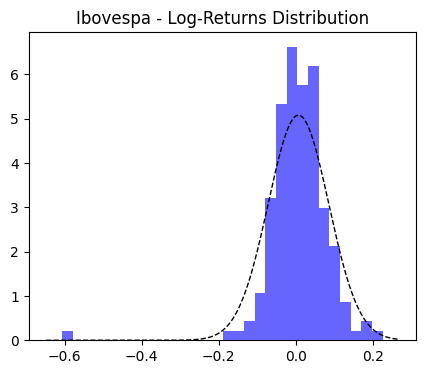

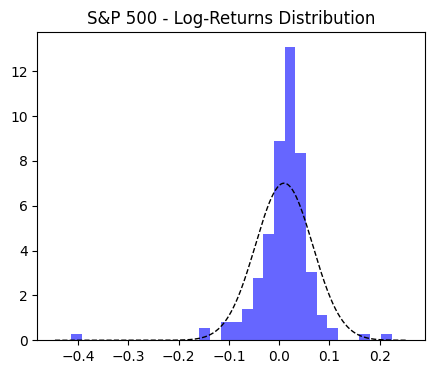

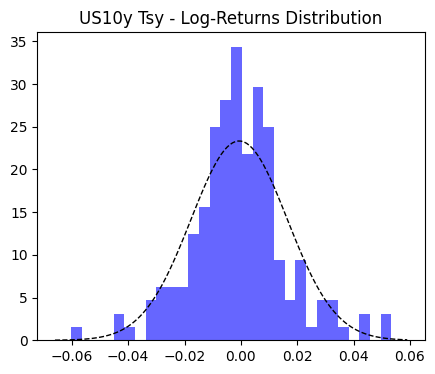

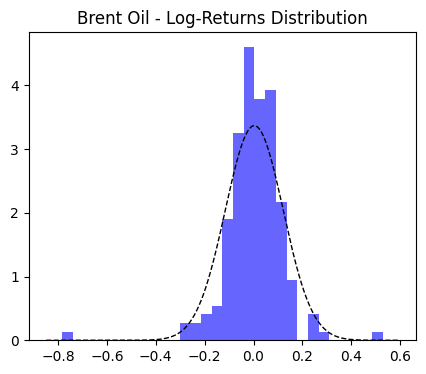

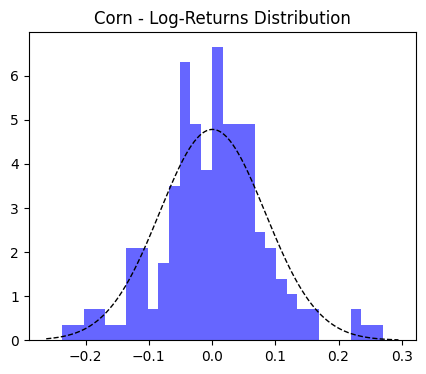

In [40]:
means = logrets.mean().values
vols = logrets.std().values

for i, col in enumerate(names):
  fig, ax = plt.subplots(figsize=(5, 4))
  plt.hist(logrets[col], bins=30, density=True, alpha=0.6, color='b')
  x_lim = ax.get_xlim()
  x_values = np.arange(x_lim[0], x_lim[1], 0.001)
  plt.plot(x_values, norm.pdf(x_values, means[i], vols[i]), color="black", linestyle='dashed', linewidth=1)
  plt.title("%s - Log-Returns Distribution" % col)
  plt.show()

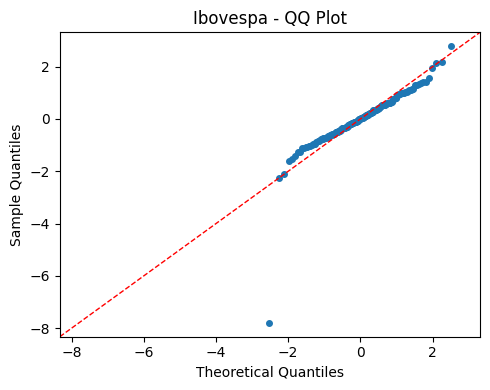

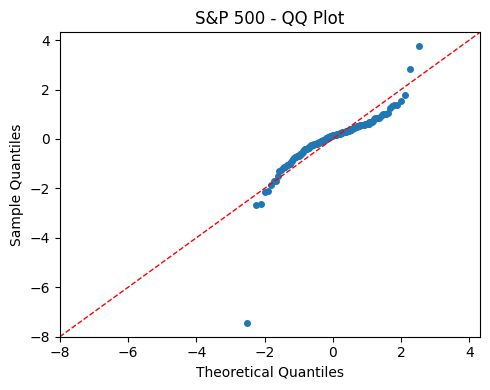

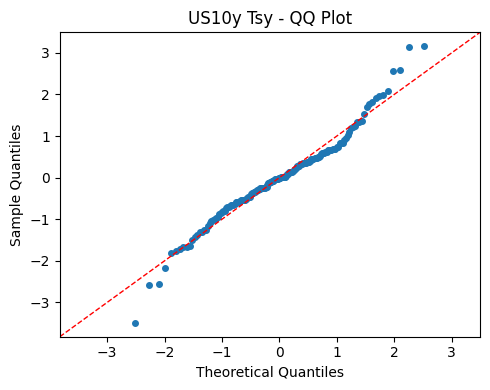

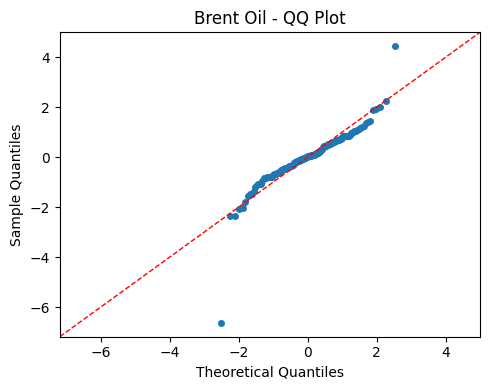

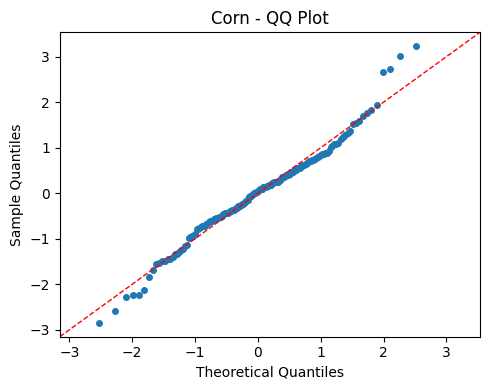

In [41]:
means = logrets.mean().values
vols = logrets.std().values

for i, col in enumerate(names):
  norm_logrets = (logrets[col] - means[i]) / vols[i]
  fig, ax = plt.subplots(figsize=(5, 4))
  # sm.qqplot(logrets[col], loc=means[i], scale=vols[i], line="45", ax=ax, markersize=4)
  sm.qqplot(norm_logrets, line="45", ax=ax, markersize=4)
  plt.setp(ax.get_lines()[1], linewidth=1, linestyle="dashed")
  plt.title("%s - QQ Plot" % col)
  plt.tight_layout()
  plt.show()

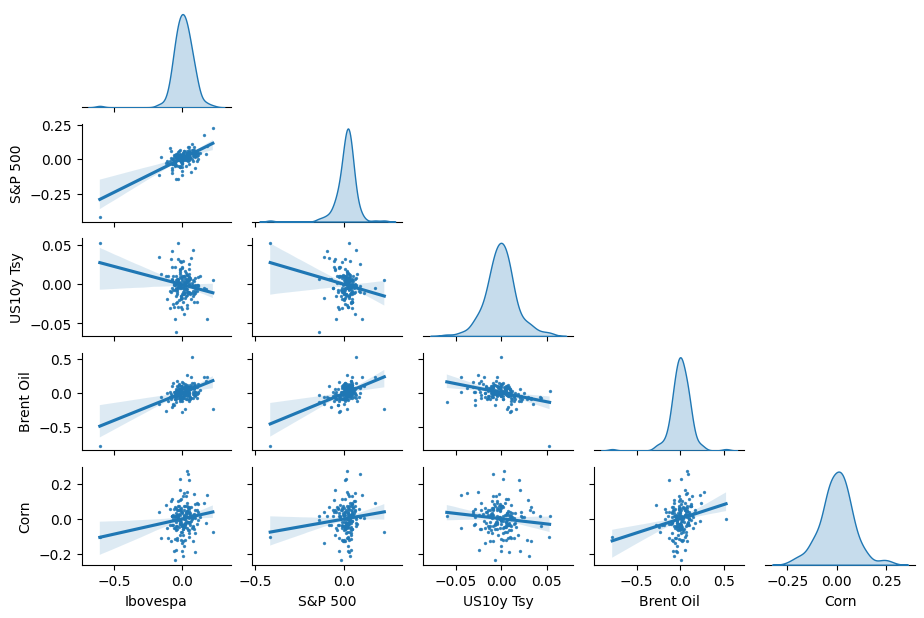

In [42]:
sns.pairplot(logrets, kind="reg", diag_kind="kde", corner=True, height=1.25, aspect=1.5, plot_kws=dict(scatter_kws=dict(s=2)))
plt.show()

In [43]:
pd.Series(np.round(means, decimals=6), index=names, name="Mean").to_frame()

,Mean
Ibovespa,0.006977
S&P 500,0.009600
US10y Tsy,-0.000604
Brent Oil,0.002902
Corn,0.000607


In [44]:
pd.Series(np.round(vols, decimals=4), index=names, name="Vol").to_frame()

,Vol
Ibovespa,0.0786
S&P 500,0.0570
US10y Tsy,0.0171
Brent Oil,0.1184
Corn,0.0834


In [45]:
np.round(logrets.corr(method="pearson"), decimals=2)

,Ibovespa,S&P 500,US10y Tsy,Brent Oil,Corn
Ibovespa,1.00,0.67,-0.21,0.54,0.16
S&P 500,0.67,1.00,-0.22,0.52,0.12
US10y Tsy,-0.21,-0.22,1.00,-0.38,-0.12
Brent Oil,0.54,0.52,-0.38,1.00,0.23
Corn,0.16,0.12,-0.12,0.23,1.00


In [46]:
np.round(logrets.cov(), decimals=8)

,Ibovespa,S&P 500,US10y Tsy,Brent Oil,Corn
Ibovespa,0.006174,0.002989,-0.000286,0.004981,0.001073
S&P 500,0.002989,0.003244,-0.000218,0.003530,0.000587
US10y Tsy,-0.000286,-0.000218,0.000292,-0.000774,-0.000174
Brent Oil,0.004981,0.003530,-0.000774,0.014025,0.002258
Corn,0.001073,0.000587,-0.000174,0.002258,0.006958


In [47]:
# N = len(means)
covs = (logrets.cov().values + logrets.cov().values.transpose()) / 2   # N x N
mu = np.round(means, decimals=6).reshape(-1, 1)  # N x 1

Rp = lambda ws: (ws.T @ mu)[0]  # Portfolio's Expected Return
Sp = lambda ws, covs: ws.T @ covs @ ws  # Portfolio's Variance (= Volatility^2)

w0 = [0.0 for _ in range(N)]  # Initial weights set to zero
bounds = [(0.0, 1.0) for _ in range(N)]
cons = {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
res_mvp5 = sc.optimize.minimize(fun=Sp, x0=w0, args=[covs], method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12)
print(res_mvp5)
ws_mvp5 = res_mvp5.x
Rp_mvp5 = Rp(ws_mvp5)
Volp_mvp5 = np.sqrt(Sp(ws_mvp5, covs))
display(Latex(r"$\omega = [%s]]" % ",".join("%.2f" % res_mvp5.x[i] for i in range(N))))  # MVP allocation weights
display(Latex(r"$\overline{R}_P = %.4f$" % Rp_mvp5))  # MVP expected return
display(Latex(r"$\sigma_P = %.4f$" % Volp_mvp5))  # MVP volatility (same as np.sqrt(res_mvp.fun))

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.00019991057109731706
       x: [ 1.826e-03  7.025e-02  8.582e-01  3.817e-02  3.158e-02]
     nit: 28
     jac: [ 3.998e-04  3.998e-04  3.998e-04  3.998e-04  3.998e-04]
    nfev: 168
    njev: 28


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [48]:
ws_EF5 = [ws_mvp5]
x_EF5 =[Volp_mvp5]
y_EF5 =[Rp_mvp5]

w0 = np.array([0.0 for _ in range(N)])  # Initial weights set to zero
bounds = [(0.0, 1.0) for _ in range(N)]
tgt_mus = np.arange(0.0005, 0.0095, 0.00025)
for i, tgt_mu in enumerate(tgt_mus):

  cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: Rp(ws) - tgt_mu}  # Rp(ws) >= tgt_mu => Rp(ws) - tgt_mu >= 0.0
  ]
  res = sc.optimize.minimize(fun=Sp, x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-012)

  ws_i5 = res.x
  Rp_i5 = Rp(ws_i5)
  Volp_i5 = np.sqrt(Sp(ws_i5, covs))

  print("Optimization %i/%i (success: %s): %s (Rp=%.6f, Volp=%.6f, ws_sum=%.2f)" % (i + 1, len(tgt_mus), res.success, res.message, Rp_i5, Volp_i5, np.sum(ws_i5)))

  ws_EF5.append(ws_i5)
  x_EF5.append(Volp_i5)
  y_EF5.append(Rp_i5)

Optimization 1/36 (success: True): Optimization terminated successfully (Rp=0.000500, Volp=0.014181, ws_sum=1.00)
Optimization 2/36 (success: True): Optimization terminated successfully (Rp=0.000750, Volp=0.014348, ws_sum=1.00)
Optimization 3/36 (success: True): Optimization terminated successfully (Rp=0.001000, Volp=0.014640, ws_sum=1.00)
Optimization 4/36 (success: True): Optimization terminated successfully (Rp=0.001250, Volp=0.015048, ws_sum=1.00)
Optimization 5/36 (success: True): Optimization terminated successfully (Rp=0.001500, Volp=0.015563, ws_sum=1.00)
Optimization 6/36 (success: True): Optimization terminated successfully (Rp=0.001750, Volp=0.016176, ws_sum=1.00)
Optimization 7/36 (success: True): Optimization terminated successfully (Rp=0.002000, Volp=0.016885, ws_sum=1.00)
Optimization 8/36 (success: True): Optimization terminated successfully (Rp=0.002250, Volp=0.017698, ws_sum=1.00)
Optimization 9/36 (success: True): Optimization terminated successfully (Rp=0.002500, Vo

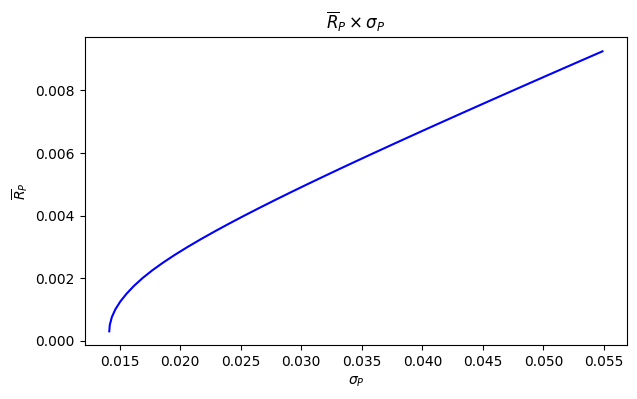

In [49]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.ylabel("$\overline{R}_P$")

plt.plot(x_EF5, y_EF5, color="blue", label=r"-0.25 $\leqslant \omega \leqslant$ 1.25")
# plt.legend()

In [50]:
M = 1000000  # 10k different portfolios
ws = np.random.random([M, N])  # Generate random weights between 0 and 1
ws = ws / np.sum(ws, axis=1).reshape(-1, 1)  # Normalize weights such that they sum up to 1

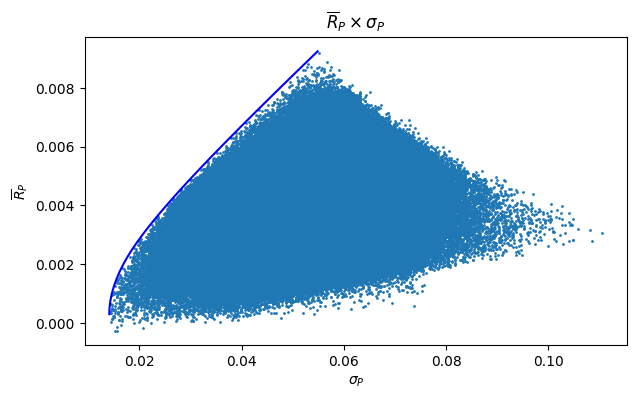

In [51]:
plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.ylabel("$\overline{R}_P$")

y = [Rp(w) for w in ws]
x = [np.sqrt(Sp(w, covs)) for w in ws]

plt.scatter(x, y, s=1)
plt.plot(x_EF5, y_EF5, color="blue", label=r"-0.25 $\leqslant \omega \leqslant$ 1.25")

In [52]:
np.round(ws_EF5[:5], decimals=2)  # Top-5 lowest risk allocations

array([[0.  , 0.07, 0.86, 0.04, 0.03],
       [0.  , 0.09, 0.84, 0.03, 0.03],
       [0.  , 0.12, 0.82, 0.03, 0.03],
       [0.  , 0.15, 0.8 , 0.02, 0.03],
       [0.  , 0.17, 0.78, 0.01, 0.03]])

In [53]:
np.round(ws_EF5[-5:], decimals=2)  # Top-5 highest risk allocations

array([[0.  , 0.87, 0.13, 0.  , 0.  ],
       [0.  , 0.89, 0.11, 0.  , 0.  ],
       [0.  , 0.92, 0.08, 0.  , 0.  ],
       [0.  , 0.94, 0.06, 0.  , 0.  ],
       [0.  , 0.97, 0.03, 0.  , 0.  ]])

Now let's see what happens when we add a risk-free asset to the universe of available instruments

In [54]:
R0 = 0.10
R1 = 0.10; S1 = 0.15
R2 = 0.30; S2 = 0.40
Rp = lambda w1: w1*R1 + (1-w1)*R2
Sp = lambda w1, p: np.sqrt(w1**2 * S1**2 + 2*w1*(1-w1)*S1*S2*p + (1-w1)**2*S2**2)

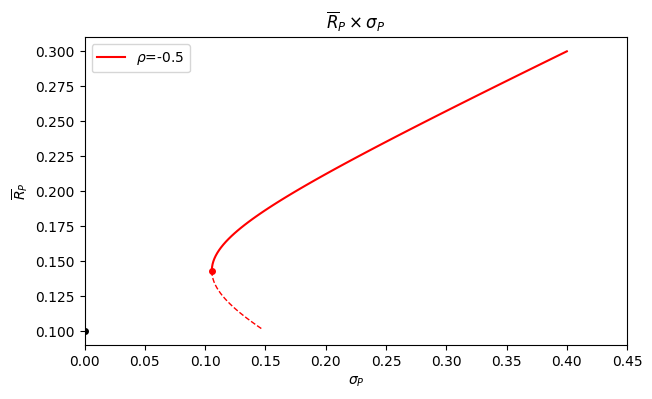

In [55]:
p = -0.5
w_mvp = (S2**2 - S1*S2*p)/(S1**2 + S2**2 - 2*S1*S2*p)

plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.45])
plt.ylabel("$\overline{R}_P$")

color="red"

# Efficient region (*i.e., with expected returns below the MVP)
w1 = np.arange(0.0, np.minimum(w_mvp, 1.01), 0.01)

y_ef = [Rp(w) for w in w1]
x_ef = [Sp(w, p) for w in w1]

plt.plot(x_ef, y_ef, color=color, label=r"$\rho$=%0.1f" % p)

# Inefficient region (*i.e., with expected returns above or equal the MVP)
w1 = np.arange(np.maximum(w_mvp, 0.0), 1.0, 0.01)

y_inef = [Rp(w) for w in w1]
x_inef = [Sp(w, p) for w in w1]

# plt.title(r"$\overline{R}_P \times \sigma_P$ for $\rho$ = %0.1f" % p)
plt.plot(x_inef, y_inef, color=color, linestyle='dashed', linewidth=1)
if w_mvp <= 1.0:
  plt.plot(Sp(w_mvp, p), Rp(w_mvp), color=color, marker='o', markersize=4)

plt.legend()

# Plot the risk-free asset
plt.plot([0], [R0], color="black", marker='o', markersize=4)

Let's assume that the risk-free asset return is $\overline{R}_0 = 0.10$

What portfolio in the original efficient frontier (i.e., which allocation weights $\omega_1$ and $\omega_2$) should we choose to get the maximum $\overline{R}_P$ for each level of $\sigma_P$?

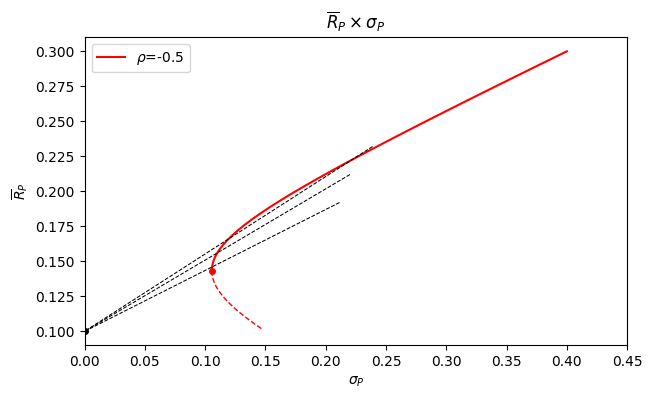

In [56]:
p = -0.5
w_mvp = (S2**2 - S1*S2*p)/(S1**2 + S2**2 - 2*S1*S2*p)

plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.45])
plt.ylabel("$\overline{R}_P$")

color="red"

# Efficient region (*i.e., with expected returns below the MVP)
w1 = np.arange(0.0, np.minimum(w_mvp, 1.01), 0.01)

y_ef = [Rp(w) for w in w1]
x_ef = [Sp(w, p) for w in w1]

plt.plot(x_ef, y_ef, color=color, label=r"$\rho$=%0.1f" % p)

# Inefficient region (*i.e., with expected returns above or equal the MVP)
w1 = np.arange(np.maximum(w_mvp, 0.0), 1.0, 0.01)

y_inef = [Rp(w) for w in w1]
x_inef = [Sp(w, p) for w in w1]

# plt.title(r"$\overline{R}_P \times \sigma_P$ for $\rho$ = %0.1f" % p)
plt.plot(x_inef, y_inef, color=color, linestyle='dashed', linewidth=1)
if w_mvp <= 1.0:
  plt.plot(Sp(w_mvp, p), Rp(w_mvp), color=color, marker='o', markersize=4)

plt.legend()

# Plot the risk-free asset
plt.plot([0], [R0], color="black", marker='o', markersize=4)

# Plot possible lines connecting the risk-free asset to a few portfolios in the original EF
i_ef = [67, 72, 77]
w0s = np.arange(-1.0, 1.0, 0.01)  # Allow 100% borrowing from at the risk-free rate
for i in range(len(i_ef)):
  Rm = y_ef[i_ef[i]]
  Sigm = x_ef[i_ef[i]]
  # m = (Rm - R0) / (Sigm - 0) # m = (y - y0)/(x - x0)

  y_line = [w0*R0 + (1-w0)*Rm for w0 in w0s]
  x_line = [(1-w0)*Sigm for w0 in w0s]
  # plt.plot(Sigm, Rm, color="black", marker='o', markersize=3)
  plt.plot(x_line, y_line, color="black", linewidth=0.75, linestyle="--")

Text([0.19138477], [0.27671441], 'New Efficient\nFrontier')

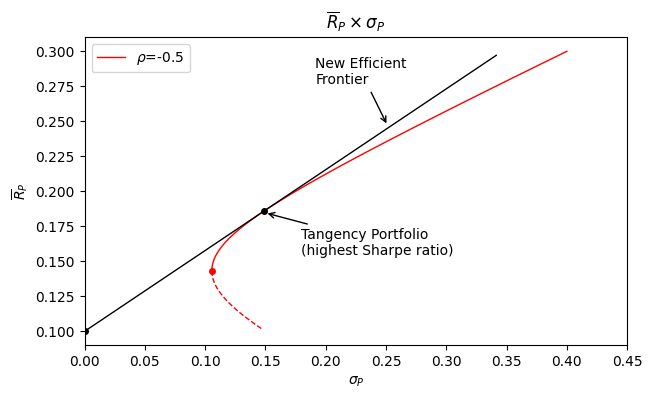

In [57]:
p = -0.5
w_mvp = (S2**2 - S1*S2*p)/(S1**2 + S2**2 - 2*S1*S2*p)

plt.figure(figsize=(7, 4))
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.45])
plt.ylabel("$\overline{R}_P$")

color="red"

# Efficient region (*i.e., with expected returns below the MVP)
w1 = np.arange(0.0, np.minimum(w_mvp, 1.01), 0.01)

y_ef = [Rp(w) for w in w1]
x_ef = [Sp(w, p) for w in w1]

plt.plot(x_ef, y_ef, color=color, linewidth=1.0, label=r"$\rho$=%0.1f" % p)

# Inefficient region (*i.e., with expected returns above or equal the MVP)
w1 = np.arange(np.maximum(w_mvp, 0.0), 1.0, 0.01)

y_inef = [Rp(w) for w in w1]
x_inef = [Sp(w, p) for w in w1]

# plt.title(r"$\overline{R}_P \times \sigma_P$ for $\rho$ = %0.1f" % p)
plt.plot(x_inef, y_inef, color=color, linestyle='dashed', linewidth=1)
if w_mvp <= 1.0:
  plt.plot(Sp(w_mvp, p), Rp(w_mvp), color=color, marker='o', markersize=4)

plt.legend()

# Plot the risk-free asset
plt.plot([0], [R0], color="black", marker='o', markersize=4)

# Find the tangency portfolio (i.e., the portfolio with the highest Sharpe ratio)
w0 = 0
bounds = [(0.0, 1.0)]
res = sc.optimize.minimize(fun=lambda w, p: -(Rp(w) - R0)/Sp(w, p), x0=w0, method="SLSQP", args=[p], jac=None, hess=None, hessp=None, bounds=bounds, tol=1e-012)

# Plot the new EF (i.e., the line connecting the risk-free asset to the old EF portfolio that, combined with the Rf, offers the best risk-adjusted expected returns)
w = res.x
Rm = Rp(w)
Sigm = Sp(w, p)

w0s = np.arange(-1.3, 1.0, 0.01)  # Allow 130% borrowing from at the risk-free rate
y_line = [w0*R0 + (1-w0)*Rm for w0 in w0s]
x_line = [(1-w0)*Sigm for w0 in w0s]
plt.plot(Sigm, Rm, color="black", marker='o', markersize=4)
plt.plot(x_line, y_line, color="black", linewidth=1.0, linestyle="-")

# Point out the tangency portfolio
Portm = (Sigm + 0.001, Rm - 0.001)
Portm_txt = (Portm[0] + 0.030, Portm[1] - 0.030)
plt.annotate('Tangency Portfolio\n(highest Sharpe ratio)', xy=Portm, xytext=Portm_txt, arrowprops=dict(arrowstyle='->',lw=1.0))

# Point out the new efficient frontier
i=60
EF = (x_line[i] - 0.001, y_line[i] + 0.001)
EF_txt = (EF[0] - 0.060, EF[1] + 0.030)
plt.annotate('New Efficient\nFrontier', xy=EF, xytext=EF_txt, arrowprops=dict(arrowstyle='->',lw=1.0))

Let's see how to construct the Efficient Frontier considering the risk-free asset:

Approach 1

In [58]:
R0 = 0.10  # Risk-free asset return
mu = np.array([[0.0875, 0.15, 0.20, 0.25, 0.30]]).reshape(-1, 1)  # Expected Returns array N x 1
sig = np.array([[0.10, 0.175, 0.25, 0.325, 0.40]]).reshape(-1, 1)  # Volatilities array N x 1
rho = np.array(
    [[+1.00, +0.20, +0.25, +0.30, +0.35],
     [+0.20, +1.00, +0.30, +0.35, +0.40],
     [+0.25, +0.30, +1.00, +0.40, +0.45],
     [+0.30, +0.35, +0.40, +1.00, +0.50],
     [+0.35, +0.40, +0.45, +0.50, +1.00]]
)  # Correlation matrix N x N
covs = np.diag(sig.flatten()) @ rho @ np.diag(sig.flatten())  # Covariance matrix N x N

# Check if eigenvalues are positive
if np.linalg.det(covs) < 0:
  print("Not all eigenvalues of the covariance matrix are non-zero")

# Check if matrix is symmetric (accounting for possible rounding errors)
covs_rounded = np.round(covs, decimals=8)
if not np.array_equal(covs_rounded, np.transpose(covs_rounded)):
  print("Covariance matrix is not symmetric")
else:
  covs = (covs + np.transpose(covs)) / 2  # Mitigate possible rounding errors

N = mu.shape[0]

In [59]:
Rp_old = lambda ws: (ws.T @ mu)[0]  # Portfolio's Expected Return
Sp_old = lambda ws, covs: ws.T @ covs @ ws  # Portfolio's Variance (= Volatility^2)

Rp_new = lambda ws, r0: (ws.T @ mu + (1 - np.sum(ws))*r0)[0]  # Portfolio's Expected Return
Sp_new = lambda ws, covs: ws.T @ covs @ ws  # Portfolio's Variance (= Volatility^2)

In [60]:
# Estimate the old efficient frontier (without the risk-free asset)
ws_EF6_old = []
x_EF6_old =[]
y_EF6_old =[]

w0 = np.array([0.0 for _ in range(N)])  # Initial weights set to zero
bounds = [(-0.0, 1.0) for _ in range(N)]  # Weights must be between 0 and 1
tgt_mus_old = np.arange(0.095, 0.30, 0.005)  # Targeted expected returns
for i, tgt_mu in enumerate(tgt_mus_old):

  cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
    {"type": "ineq", "fun": lambda ws: Rp_old(ws) - tgt_mu}
  ]
  res = sc.optimize.minimize(fun=Sp_old, x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12)

  ws_i6_old = res.x
  Rp_i6_old = Rp_old(ws_i6_old)
  Volp_i6_old = np.sqrt(Sp_old(ws_i6_old, covs))

  # print("Optimization %i/%i (success: %s): %s (Rp=%.6f, Volp=%.6f, ws_sum=%.2f)" % (i + 1, tgt_mus_old.shape[0], res.success, res.message, Rp_i6_old, Volp_i6_old, np.sum(ws_i6_old)))

  ws_EF6_old.append(ws_i6_old)
  x_EF6_old.append(Volp_i6_old)
  y_EF6_old.append(Rp_i6_old)

print("")

# Estimate the new efficient frontier (with the risk-free asset)
ws_EF6 = []
x_EF6 = []
y_EF6 = []

w0 = np.array([0.0 for _ in range(N)])
bounds = [(-0.0, 1.0) for _ in range(N)]

tgt_mus = np.arange(0.095, 0.40, 0.01)
for i, tgt_mu in enumerate(tgt_mus):
  cons = [
      {"type": "ineq", "fun": lambda ws: Rp_new(ws, R0) - tgt_mu}
  ]
  res = sc.optimize.minimize(fun=Sp_new, x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-012)

  ws_i6 = res.x
  Rp_i6 = Rp_new(ws_i6, R0)
  Volp_i6 = np.sqrt(Sp_new(ws_i6, covs))

  # print("Optimization %i/%i (success: %s): %s (Rp=%.6f, Volp=%.6f, ws_sum=%.2f)" % (i + 1, tgt_mus.shape[0], res.success, res.message, Rp_i6, Volp_i6, np.sum(ws_i6)))

  ws_EF6.append(ws_i6)
  x_EF6.append(Volp_i6)
  y_EF6.append(Rp_i6)

# Estimate the Market Portfolio
w0 = np.array([1/N for _ in range(N)])  # What happens when we set the initial conditions to zero here? It does not converge
bounds = [(-0.0, 1.0) for _ in range(N)]
cons = [
  {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
]
res = sc.optimize.minimize(fun=lambda w, p: -(Rp_old(w) - R0)/np.sqrt(Sp_old(w, covs)), x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-012)
wM = res.x
RM = Rp_old(wM)
VolM = np.sqrt(Sp_old(wM, covs))

Text(0.16710609207622662, 0.2838709371540117, 'Market\nPortfolio')

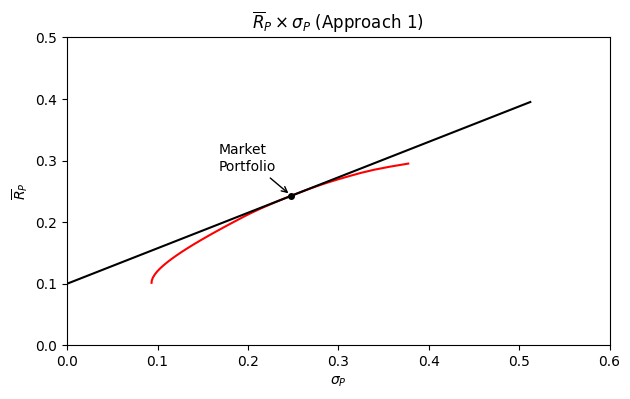

In [61]:
plt.figure(figsize=(7, 4))

# plot the old efficient frontier (without the risk-free asset)
plt.plot(x_EF6_old, y_EF6_old, color="red", label=r"Efficient Frontier")

# Plot the new efficient frontier (with the risk-free asset)
plt.title(r"$\overline{R}_P \times \sigma_P$ (Approach 1)")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.60])
plt.ylim([0.00, 0.50])
plt.ylabel("$\overline{R}_P$")
plt.plot(x_EF6, y_EF6, color="black", label=r"Efficient Frontier")

# Plot the Market Portfolio (i.e., the one with the highest Sharpe ratio)
plt.plot(VolM, RM, color="black", marker='o', markersize=4)

# Point out the tangency portfolio
M = (VolM - 0.001, RM + 0.001)
M_txt = (M[0] - 0.080, M[1] + 0.040)
plt.annotate('Market\nPortfolio', xy=M, xytext=M_txt, arrowprops=dict(arrowstyle='->',lw=1.0))

Approach 2

In [62]:
mu = np.array([[0.10, 0.0875, 0.15, 0.20, 0.25, 0.30]]).reshape(-1, 1)  # Expected Returns array N x 1
sig = np.array([[0.0, 0.10, 0.175, 0.25, 0.325, 0.40]]).reshape(-1, 1)  # Volatilities array N x 1
rho = np.array(
    [[+1.00, +0.00, +0.00, +0.00, +0.00, +0.00],
     [+0.00, +1.00, +0.20, +0.25, +0.30, +0.35],
     [+0.00, +0.20, +1.00, +0.30, +0.35, +0.40],
     [+0.00, +0.25, +0.30, +1.00, +0.40, +0.45],
     [+0.00, +0.30, +0.35, +0.40, +1.00, +0.50],
     [+0.00, +0.35, +0.40, +0.45, +0.50, +1.00]]
)  # Correlation matrix N x N
covs = np.diag(sig.flatten()) @ rho @ np.diag(sig.flatten())  # Covariance matrix N x N

# Check if eigenvalues are positive
if np.linalg.det(covs) < 0:
  print("Not all eigenvalues of the covariance matrix are non-zero")

# Check if matrix is symmetric (accounting for possible rounding errors)
covs_rounded = np.round(covs, decimals=8)
if not np.array_equal(covs_rounded, np.transpose(covs_rounded)):
  print("Covariance matrix is not symmetric")
else:
  covs = (covs + np.transpose(covs)) / 2  # Mitigate possible rounding errors

N = mu.shape[0]

In [63]:
Rp_new2 = lambda ws: (ws.T @ mu)[0]  # Portfolio's Expected Return
Sp_new2 = lambda ws, covs: ws.T @ covs @ ws  # Portfolio's Variance (= Volatility^2)

In [64]:
# Estimate the new efficient frontier (with the risk-free asset)
ws_EF6_2 = []
x_EF6_2 = []
y_EF6_2 = []

w0 = np.array([0.0 for _ in range(N)])
bounds = [(-1.00, 2.00)] + [(-0.0, 1.0) for _ in range(N-1)]

tgt_mus = np.arange(0.095, 0.40, 0.01)
for i, tgt_mu in enumerate(tgt_mus):
  cons = [
      {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},
      {"type": "ineq", "fun": lambda ws: Rp_new2(ws) - tgt_mu}
  ]
  res = sc.optimize.minimize(fun=Sp_new2, x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-012)

  ws_i6_2 = res.x
  Rp_i6_2 = Rp_new2(ws_i6_2)
  Volp_i6_2 = np.sqrt(Sp_new2(ws_i6_2, covs))

  # print("Optimization %i/%i (success: %s): %s (Rp=%.6f, Volp=%.6f, ws_sum=%.2f)" % (i + 1, tgt_mus.shape[0], res.success, res.message, Rp_i6_2, Volp_i6_2, np.sum(ws_i6_2)))

  ws_EF6_2.append(ws_i6_2)
  x_EF6_2.append(Volp_i6_2)
  y_EF6_2.append(Rp_i6_2)

Text(0.16710609207622662, 0.2838709371540117, 'Market\nPortfolio')

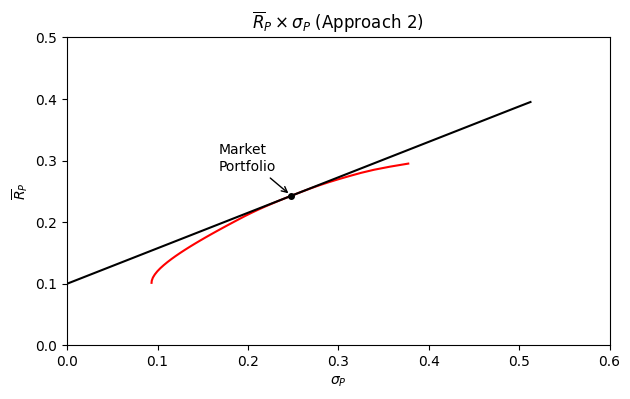

In [65]:
plt.figure(figsize=(7, 4))

# plot the old efficient frontier (without the risk-free asset)
plt.plot(x_EF6_old, y_EF6_old, color="red", label=r"Efficient Frontier")

# Plot the new efficient frontier (with the risk-free asset)
plt.title(r"$\overline{R}_P \times \sigma_P$ (Approach 2)")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.60])
plt.ylim([0.00, 0.50])
plt.ylabel("$\overline{R}_P$")
plt.plot(x_EF6_2, y_EF6_2, color="black", label=r"Efficient Frontier")

# Plot the Market Portfolio (i.e., the one with the highest Sharpe ratio)
plt.plot(VolM, RM, color="black", marker='o', markersize=4)

# Point out the tangency portfolio
M = (VolM - 0.001, RM + 0.001)
M_txt = (M[0] - 0.080, M[1] + 0.040)
plt.annotate('Market\nPortfolio', xy=M, xytext=M_txt, arrowprops=dict(arrowstyle='->',lw=1.0))

Approach 3

In [66]:
R0 = 0.10  # Risk-free asset return
mu = np.array([[0.0875, 0.15, 0.20, 0.25, 0.30]]).reshape(-1, 1)  # Expected Returns array N x 1
sig = np.array([[0.10, 0.175, 0.25, 0.325, 0.40]]).reshape(-1, 1)  # Volatilities array N x 1
rho = np.array(
    [[+1.00, +0.20, +0.25, +0.30, +0.35],
     [+0.20, +1.00, +0.30, +0.35, +0.40],
     [+0.25, +0.30, +1.00, +0.40, +0.45],
     [+0.30, +0.35, +0.40, +1.00, +0.50],
     [+0.35, +0.40, +0.45, +0.50, +1.00]]
)  # Correlation matrix N x N
covs = np.diag(sig.flatten()) @ rho @ np.diag(sig.flatten())  # Covariance matrix N x N

# Check if eigenvalues are positive
if np.linalg.det(covs) < 0:
  print("Not all eigenvalues of the covariance matrix are non-zero")

# Check if matrix is symmetric (accounting for possible rounding errors)
covs_rounded = np.round(covs, decimals=8)
if not np.array_equal(covs_rounded, np.transpose(covs_rounded)):
  print("Covariance matrix is not symmetric")
else:
  covs = (covs + np.transpose(covs)) / 2  # Mitigate possible rounding errors

N = mu.shape[0]

In [67]:
# (Re)estimate the Market Portfolio
w0 = np.array([1/N for _ in range(N)])  # What happens when we set the initial conditions to zero here? It does not converge
bounds = [(-0.0, 1.0) for _ in range(N)]
cons = [
  {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
]
res = sc.optimize.minimize(fun=lambda w, p: -(Rp_old(w) - R0)/np.sqrt(Sp_old(w, covs)), x0=w0, method="SLSQP", args=[covs], jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-012)
wM = res.x
RM = Rp_old(wM)
VolM = np.sqrt(Sp_old(wM, covs))

In [68]:
# Estimate the new efficient frontier (with the risk-free asset)
ws_EF6_3 = []
x_EF6_3 = []
y_EF6_3 = []

w0 = np.array([0.0])
bounds = np.array([(-0.75, 1.75)])

tgt_mus = np.arange(0.10, 0.40, 0.01)
for i, tgt_mu in enumerate(tgt_mus):

  ws_i6_3 = (tgt_mu - R0) / (RM - R0)
  Rp_i6_3 = tgt_mu
  Volp_i6_3 = ws_i6_3 * VolM

  ws_EF6_3.append(ws_i6_3)
  x_EF6_3.append(Volp_i6_3)
  y_EF6_3.append(Rp_i6_3)

Text(0.16710609207622662, 0.2838709371540117, 'Market\nPortfolio')

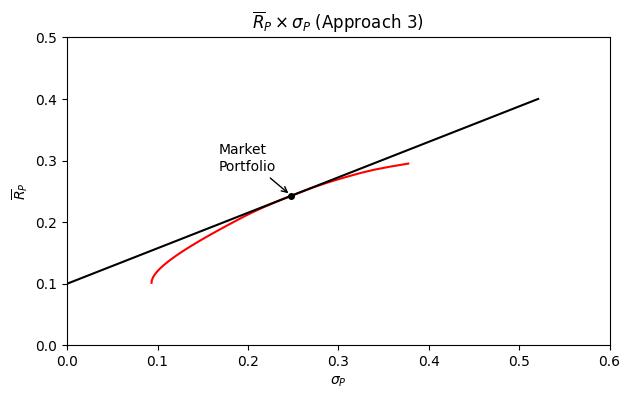

In [69]:
plt.figure(figsize=(7, 4))

# plot the old efficient frontier (without the risk-free asset)
plt.plot(x_EF6_old, y_EF6_old, color="red", label=r"Efficient Frontier")

# Plot the new efficient frontier (with the risk-free asset)
plt.title(r"$\overline{R}_P \times \sigma_P$ (Approach 3)")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.60])
plt.ylim([0.00, 0.50])
plt.ylabel("$\overline{R}_P$")
plt.plot(x_EF6_3, y_EF6_3, color="black", label=r"Efficient Frontier")

# Plot the Market Portfolio (i.e., the one with the highest Sharpe ratio)
plt.plot(VolM, RM, color="black", marker='o', markersize=4)

# Point out the tangency portfolio
M = (VolM - 0.001, RM + 0.001)
M_txt = (M[0] - 0.080, M[1] + 0.040)
plt.annotate('Market\nPortfolio', xy=M, xytext=M_txt, arrowprops=dict(arrowstyle='->',lw=1.0))

Case 5 - Portfolio Optimization based on Quadratic Utility

In [70]:
mu = np.array([[0.0875, 0.15, 0.20, 0.25, 0.30]]).reshape(-1, 1)  # Expected Returns array N x 1
sig = np.array([[0.10, 0.175, 0.25, 0.325, 0.40]]).reshape(-1, 1)  # Volatilities array N x 1
rho = np.array(
    [[+1.00, +0.20, +0.25, +0.30, +0.35],
     [+0.20, +1.00, +0.30, +0.35, +0.40],
     [+0.25, +0.30, +1.00, +0.40, +0.45],
     [+0.30, +0.35, +0.40, +1.00, +0.50],
     [+0.35, +0.40, +0.45, +0.50, +1.00]]
)  # Correlation matrix N x N
covs = np.diag(sig.flatten()) @ rho @ np.diag(sig.flatten())  # Covariance matrix N x N

# Check if eigenvalues are positive
if np.linalg.det(covs) < 0:
  print("Not all eigenvalues of the covariance matrix are non-zero")

# Check if matrix is symmetric (accounting for possible rounding errors)
covs_rounded = np.round(covs, decimals=8)
if not np.array_equal(covs_rounded, np.transpose(covs_rounded)):
  print("Covariance matrix is not symmetric")
else:
  covs = (covs + np.transpose(covs)) / 2  # Mitigate possible rounding errors

N = mu.shape[0]

In [71]:
obj_fun = lambda ws, covs, mu, lamb: -(ws.T @ mu - 0.5 * lamb * ws.T @ covs @ ws)[0]  # Quadratic utility as an objective function

In [72]:
# Estimate the old efficient frontier (without the risk-free asset)
ws_EF7 = []
x_EF7 =[]
y_EF7 =[]
lbd_EF7 = []

w0 = np.array([1/N for _ in range(N)])  # Initial weights set to zero
bounds = [(-0.0, 1.0) for _ in range(N)]  # Weights must be between 0 and 1
tgt_lambdas = np.concatenate((np.arange(0.50, 1.00, 0.1), np.round(np.exp(np.arange(0.0, 5.00, 0.10)), decimals=2)))  # Target risk aversions

for i, tgt_lambda in enumerate(tgt_lambdas):

  cons = [
    {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0}  # Weights must sum up to 1
  ]
  res = sc.optimize.minimize(fun=obj_fun, x0=w0, method="SLSQP", args=(covs, mu, tgt_lambda), jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12)

  ws_i7 = res.x
  Rp_i7 = (ws_i7.T @ mu)[0]
  Volp_i7 = np.sqrt(ws_i7.T @ covs @ ws_i7)

  # print("Optimization %i/%i (success: %s): %s (Lambda=%.2f, Rp=%.6f, Volp=%.6f, ws_sum=%.2f)" % (i + 1, tgt_lambdas.shape[0], res.success, res.message, tgt_lambda, Rp_i7, Volp_i7, np.sum(ws_i7)))

  ws_EF7.append(ws_i7)
  x_EF7.append(Volp_i7)
  y_EF7.append(Rp_i7)
  lbd_EF7.append(tgt_lambda)

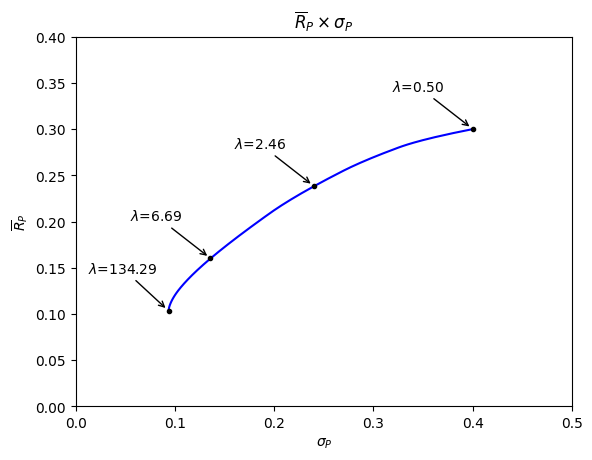

In [73]:
# Plot the efficient frontier
plt.title(r"$\overline{R}_P \times \sigma_P$")
plt.xlabel("$\sigma_P$")
plt.xlim([0.0, 0.50])
plt.ylim([0.00, 0.40])
plt.ylabel("$\overline{R}_P$")
plt.plot(x_EF7, y_EF7, color="blue", label=r"Efficient Frontier")

# Point out a few lambda values
inds_lambdas = [0, 14, 24, 54]
for i in inds_lambdas:
  lbd = (x_EF7[i] - 0.001, y_EF7[i] + 0.001)
  lbd_txt = (lbd[0] - 0.080, lbd[1] + 0.040)
  plt.annotate("$\lambda$=%.2f" % lbd_EF7[i], xy=lbd, xytext=lbd_txt, arrowprops=dict(arrowstyle='->',lw=1.0))
  plt.plot(x_EF7[i], y_EF7[i], color="black", marker='o', markersize=3)

BH, EW and MV Portfolio Comparison

First, let's obtain the historical prices from some stocks

In [74]:
# Get stock index prices
start_date = "2008-12-31"
end_date = "2023-12-31"
names = ["Lowe's Cos", "Caterpillar", "Abbott Laboratories", "Comcast", "Energy Transfer", "Colgate-Palmolive", "iShares Money Market ETF"]
tickers = ["LOW", "CAT", "AB", "CMCSA", "ET", "ATO", "CMR.TO"]
prices = pd.DataFrame(columns=names, dtype=float)
for i, ticker in enumerate(tickers):
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
  prices[names[i]] = data["Adj Close"].rename(names[i])

prices.dropna(inplace=True)  # Drop nans (not the best approach to deal with missing values)
k = 1  # Non-overlapping log-returns
logrets = np.log1p(prices.iloc[::k, :].pct_change())
logrets.dropna(inplace=True)

rf = logrets["iShares Money Market ETF"]
logrets = logrets[["Lowe's Cos", "Caterpillar", "Abbott Laboratories", "Comcast", "Energy Transfer", "Colgate-Palmolive"]]

In [75]:
print("Sample size: %i log-returns between %s and %s" % (len(logrets), logrets.index[0].strftime("%d/%m/%Y"), logrets.index[-1].strftime("%d/%m/%Y")))

Sample size: 3695 log-returns between 02/01/2009 and 29/12/2023


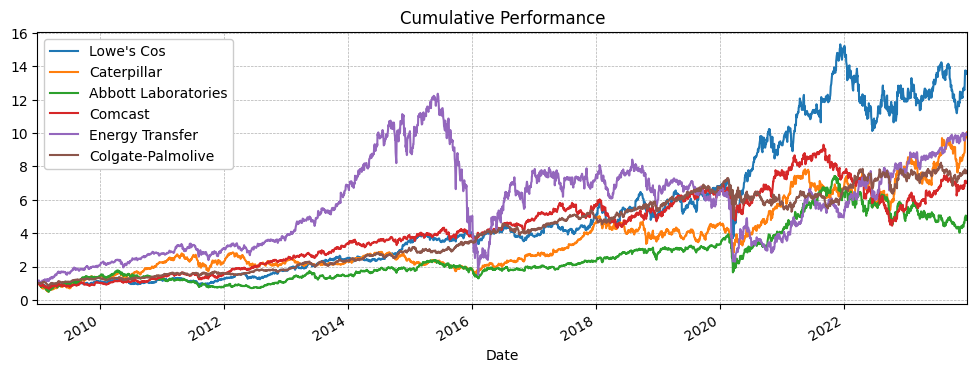

In [76]:
cum_perf = np.exp(logrets.cumsum())
cum_perf.loc[prices.index[0]] = 1.0
cum_perf = cum_perf.sort_index()
ax = cum_perf.plot(title="Cumulative Performance", figsize=(12,4))
ax.xaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.yaxis.grid(True, which='major',  linestyle='--', linewidth=0.5)
ax.set_xlim((cum_perf.index[0], cum_perf.index[-1]))
ax.legend(framealpha=1.0)

Then, let's perform a backtest (BT) for each model (BH, EW and MV)

In [77]:
T = len(logrets)
T_training = 5 * 252

start_i = T_training + 1
prev_i = start_i - 1
end_i = T

trns_costs = 0.0015  # 0.15% of the amount bought or sold

models = ["BH", "EW", "MV"]
# models = ["BH", "EW"]
M = len(models)
N = len(names[:-1])

port_ws = dict()
port_logrets = dict()
for m in range(M):
  port_ws[models[m]] = pd.DataFrame(index=logrets.index[prev_i:end_i], columns=names[:-1], dtype=float)
  port_logrets[models[m]] = pd.Series(index=logrets.index[prev_i:end_i], dtype=float)

  port_ws[models[m]].iloc[0, :] = 0.0
  port_logrets[models[m]].iloc[0] = 0.0

# Get the rebalancing dates
rebal_dates = port_ws["EW"].loc[port_ws["EW"].groupby(port_ws["EW"].index.to_period('M')).apply(lambda d: d.index.max())].index.to_list()

first_rebal = True
prev_date = logrets.index[prev_i]
for i in range(start_i, end_i):

  curr_date = logrets.index[i]

  # Compute the daily performance of each portfolio
  rets = np.expm1(logrets.loc[curr_date])
  for m in range(M):
    port_ret = np.sum(port_ws[models[m]].loc[prev_date] * rets)
    port_logrets[models[m]].loc[curr_date] = np.log1p(port_ret)

    # Update the portfolio weights due to drift
    adj_ws = port_ws[models[m]].loc[prev_date] * (1 + rets)
    if np.sum(adj_ws) > 0:
        port_ws[models[m]].loc[curr_date, :] = adj_ws / np.sum(adj_ws)  # Normalize weights
    else:
      port_ws[models[m]].loc[curr_date, :] = 0.0

  # Check if it is a rebalancing date
  if curr_date in rebal_dates:

    # BH Portfolio
    if first_rebal:
      # Set BH initial weights to 1/N
      old_ws = port_ws["BH"].loc[curr_date, :].copy(deep=True)
      port_ws["BH"].loc[curr_date, :] = 1.0 / N  # New weights
      delta_ws = np.abs(port_ws["BH"].loc[curr_date, :] - old_ws)
      rebal_trns_costs = np.sum(delta_ws * trns_costs)
      port_logrets["BH"].loc[curr_date] -= np.log1p(rebal_trns_costs)

      first_rebal = False
      i_first_alloc = i - start_i

    # EW Portfolio
    old_ws = port_ws["EW"].loc[curr_date, :].copy(deep=True)
    port_ws["EW"].loc[curr_date, :] = 1.0 / N  # New weights
    delta_ws = np.abs(port_ws["EW"].loc[curr_date, :] - old_ws)
    rebal_trns_costs = np.sum(delta_ws * trns_costs)
    port_logrets["EW"].loc[curr_date] -= np.log1p(rebal_trns_costs)

    # MV Portfolio
    old_ws = port_ws["MV"].loc[curr_date, :].copy(deep=True)

    # Estimate expected returns and covariances (and, consequently, volatilities and correlations)
    mus = np.array(logrets.iloc[i-T_training-1:i-1, :].mean()).reshape(-1, 1)  # N x 1
    covs = np.array(logrets.iloc[i-T_training-1:i-1, :].cov().values)

    # Choose target volatility to match the current volatility of a EW portfolio
    EW_var = (np.array([1.0/N for _ in range(N)]) @ covs @ np.array([[1.0/N] for _ in range(N)]))[0]

    # Find optimal MV weights
    w0 = np.array([1.0/N for _ in range(N)])
    bounds = [(-0.0, 1.0) for _ in range(N)]
    cons = [
        {"type": "eq", "fun": lambda ws: np.sum(ws) - 1.0},  # Weights must sum up to 1
        {"type": "ineq", "fun": lambda ws: -ws.T @ covs @ ws + EW_var}
    ]
    res = sc.optimize.minimize(fun=lambda ws: - ws.T @ mus, x0=w0, method="SLSQP", jac=None, hess=None, hessp=None, bounds=bounds, constraints=cons, tol=1e-12)

    if not res.success:
      raise ValueError("MV optimization did not converged at rebalancing date '%s'" % curr_date.strftime("%d-%m-%Y"))

    # Update weights and compute transaction costs
    port_ws["MV"].loc[curr_date, :] = res.x
    delta_ws = np.abs(port_ws["MV"].loc[curr_date, :] - old_ws)
    rebal_trns_costs = np.sum(delta_ws * trns_costs)
    port_logrets["MV"].loc[curr_date] -= np.log1p(rebal_trns_costs)

  prev_date = curr_date

Plot the portfolios' results

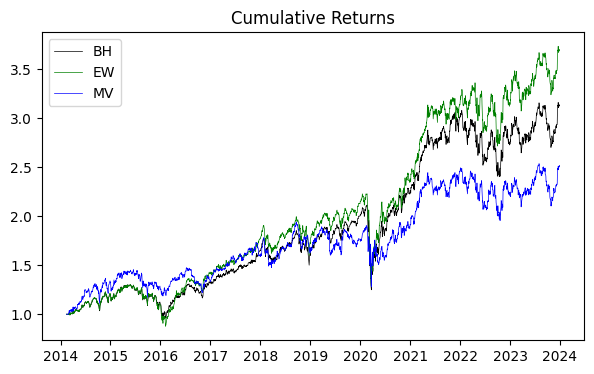

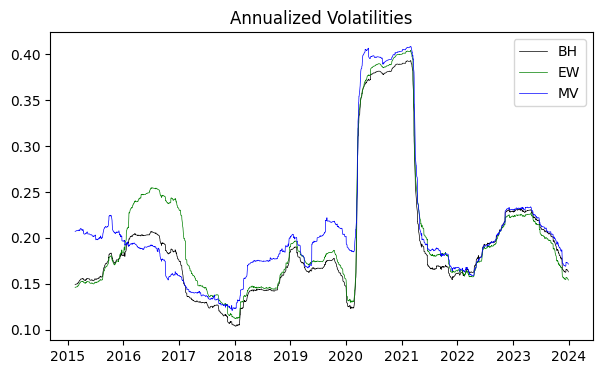

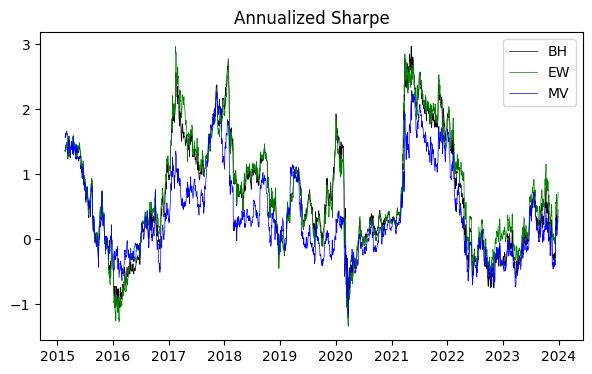

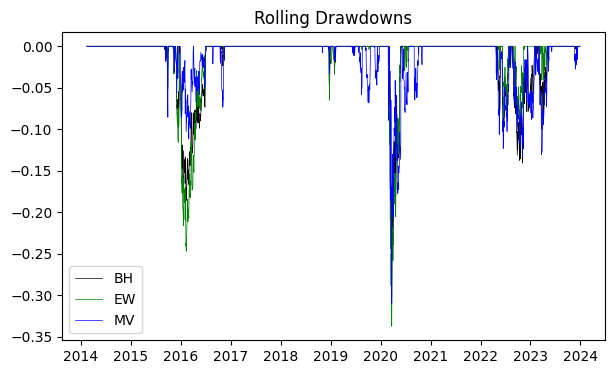

<Figure size 700x400 with 0 Axes>

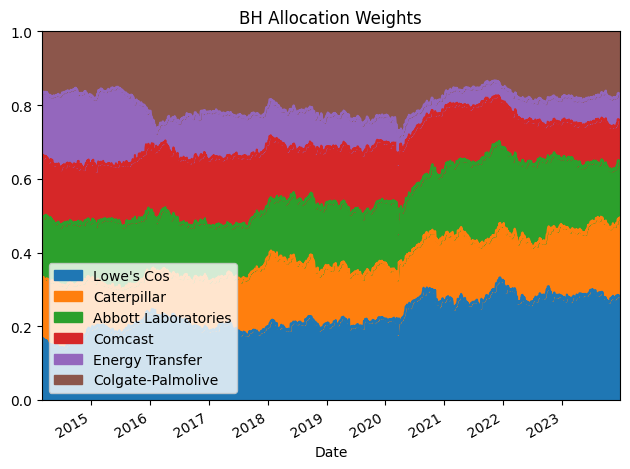

<Figure size 700x400 with 0 Axes>

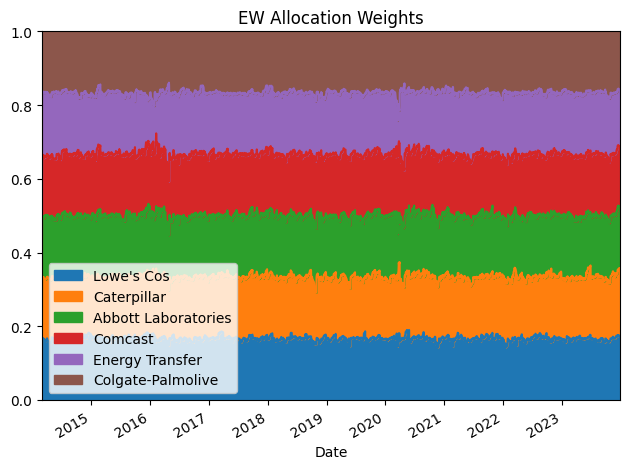

<Figure size 700x400 with 0 Axes>

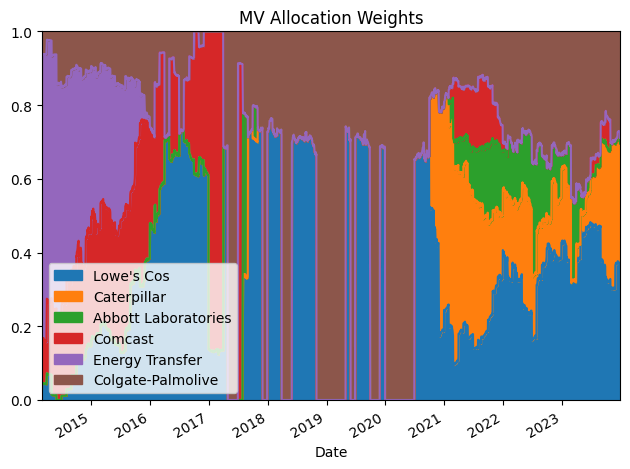

In [78]:
# Cumulative Performance
plt.figure(figsize=(7,4))
colors = ["black", "green", "blue"]
for m in range(M):
    plt.plot(np.exp(port_logrets[models[m]].cumsum()), label=models[m], color=colors[m], linewidth=0.5)
plt.title("Cumulative Returns")
plt.legend()

# Portfolios' Rolling Volatilities
plt.figure(figsize=(7,4))
colors = ["black", "green", "blue"]
for m in range(M):
    plt.plot(port_logrets[models[m]].rolling(252).std() * np.sqrt(252), label=models[m], color=colors[m], linewidth=0.5)
plt.title("Annualized Volatilities")
plt.legend()

# Portfolios' Rolling Sharpe Ratios
plt.figure(figsize=(7,4))
colors = ["black", "green", "blue"]
rf_logret = rf.rolling(window=252).sum()
for m in range(M):
    port_ann_logret = port_logrets[models[m]].rolling(window=252).sum()
    exc_ann_logret = port_ann_logret - rf_logret
    port_ann_vol = port_logrets[models[m]].rolling(252).std() * np.sqrt(252)
    plt.plot(exc_ann_logret / port_ann_vol, label=models[m], color=colors[m], linewidth=0.5)
plt.title("Annualized Sharpe")
plt.legend()

# Portfolio's Rolling Drawdowns
plt.figure(figsize=(7,4))
colors = ["black", "green", "blue"]
rf_logret = rf.rolling(window=252).sum()
for m in range(M):
    port_acc_rets = np.exp(port_logrets[models[m]].cumsum())
    port_dds = np.minimum(((port_acc_rets.div(port_acc_rets.shift(252)) - 1.0).fillna(0.0)), 0.0)
    plt.plot(port_dds, label=models[m], color=colors[m], linewidth=0.5)
plt.title("Rolling Drawdowns")
plt.legend()

# Portfolios' Allocation Weights
for m in range(M):
    plt.figure(figsize=(7,4))
    port_ws[models[m]].plot.area(stacked=True)
    plt.title("%s Allocation Weights" % models[m])
    plt.legend(loc="lower left")
    plt.xlim([port_ws[models[m]].index[i_first_alloc], port_ws[models[m]].index[-1]])
    plt.ylim([0.0, 1.0])
    plt.tight_layout()

<Figure size 700x400 with 0 Axes>

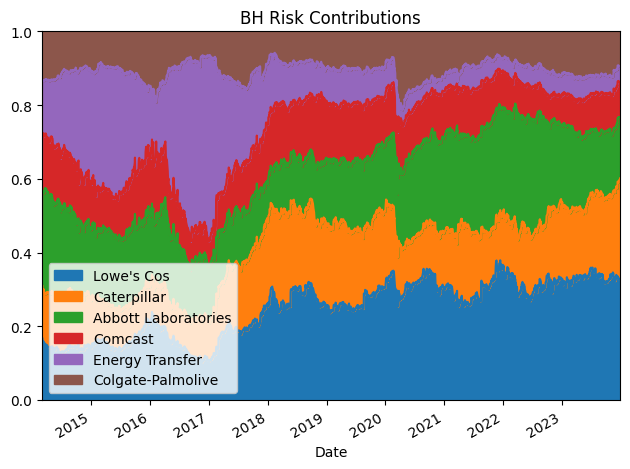

<Figure size 700x400 with 0 Axes>

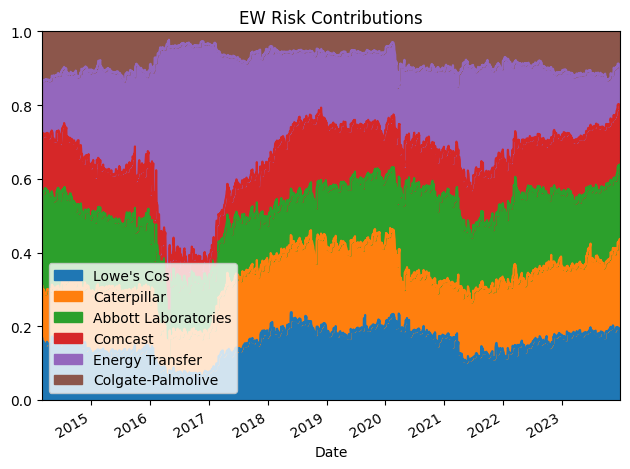

<Figure size 700x400 with 0 Axes>

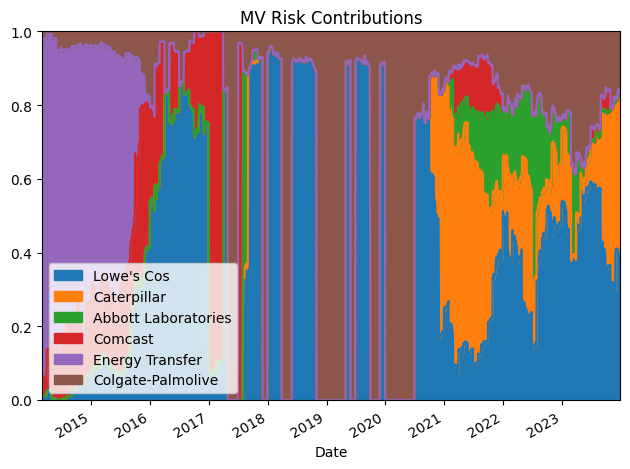

In [79]:
# Portfolios' Percentual Risk Contributions
port_rcs = dict()
for m in range(M):
    port_rcs[models[m]] = pd.DataFrame(index=port_ws[models[m]].index[i_first_alloc:end_i], columns=names[:-1], dtype=float)
    for curr_date in port_ws[models[m]].index[i_first_alloc + 1:]:
        covs = np.array(logrets.loc[:curr_date].iloc[-252:, :].cov().values)
        ws = port_ws[models[m]].loc[curr_date, :].values
        total_risk = np.sqrt(ws @ covs @ ws.reshape(-1, 1))[0]
        if total_risk > 0:
            mcs = ws @ covs / total_risk
            cs = ws * mcs
            pcs= cs / total_risk
            port_rcs[models[m]].loc[curr_date, :] = np.nan_to_num(np.clip(pcs, 0.0, np.inf))
        else:
           port_rcs[models[m]].loc[curr_date, :] = 0.0

for m in range(M):
    plt.figure(figsize=(7,4))
    port_rcs[models[m]].plot.area(stacked=True)
    plt.title("%s Risk Contributions" % models[m])
    plt.legend(loc="lower left")
    plt.xlim([port_ws[models[m]].index[i_first_alloc], port_ws[models[m]].index[-1]])
    plt.ylim([0.0, 1.0])
    plt.tight_layout()


Let's conclude our MV optimization section with a few important remarks:

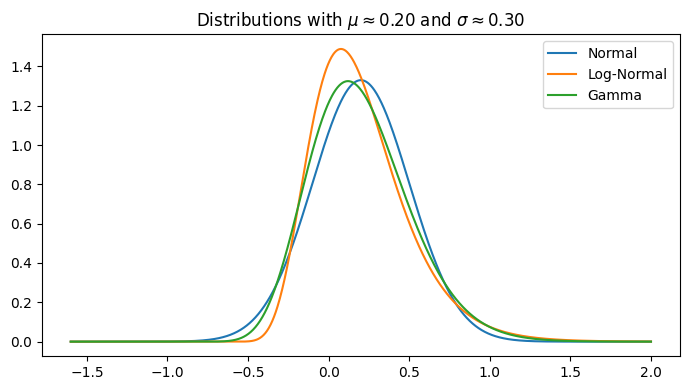

In [80]:
mu = 0.20
sig = 0.30
k = 6

# Construct Normal, Log-Normal and Gamma distributions with same mu and sigma
rvs = dict()
pdfs = dict()

rvs["normal"] = sc.stats.norm(loc=mu, scale=sig)

rv0 = sc.stats.lognorm(s=sig)
std0 = rv0.std()
rv1 = sc.stats.lognorm(s=sig,scale=sig/std0)
mu1 = rv1.mean()
rvs["lognormal"] = sc.stats.lognorm(s=sig, loc=mu - mu1, scale=sig / std0)

rvs["gamma"] = sc.stats.gamma(a=15, loc=-1.0, scale=0.08)

x = np.linspace(mu - k*sig, mu + k*sig, 1000)
pdfs["normal"] = rvs["normal"].pdf(x)
pdfs["lognormal"] = rvs["lognormal"].pdf(x)
pdfs["gamma"] = rvs["gamma"].pdf(x)

plt.figure(figsize=(7,4))
plt.title(r"Distributions with $\mu \approx$%.2f and $\sigma \approx$%.2f" % (mu, sig))
plt.plot(x, pdfs["normal"], label="Normal")
plt.plot(x, pdfs["lognormal"], label="Log-Normal")
plt.plot(x, pdfs["gamma"], label="Gamma")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
dists = ["normal", "lognormal", "gamma"]
df_moments = pd.DataFrame(index=dists, columns=["mean", "sigma", "skewness", "(exc) kurtosis"], dtype=float)
for dist in dists:
  df_moments.loc[dist, :] = rvs[dist].stats(moments="mvsk")
  df_moments.loc[dist, "sigma"] = np.round(df_moments.loc[dist, "sigma"]**0.5, decimals=2)

In [82]:
np.round(df_moments[["skewness", "(exc) kurtosis"]], decimals=2)

,skewness,(exc) kurtosis
normal,0.00,0.00
lognormal,0.95,1.64
gamma,0.52,0.40
